In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64,garbage_collection_threshold:0.6"

import sys
import gtfparse
from matplotlib.backend_bases import NonGuiException
import numpy as np
import pandas as pd
from pathlib import Path
import logging
import json
import muon as mu
from sklearn.metrics import roc_auc_score

import torch
import argparse

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR.parent / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"

import utils
from utils import prepare_tftg_lookup_tables, build_tftg_inputs

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

2026-09-22 11:47:05.537590: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-22 11:47:11.716201: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
mdata = mu.read_h5mu(DATA_DIR / "processed/mESC/E8.5_rep1/multiome_processed.h5mu")
rna_adata = mdata.mod['rna']

rna_adata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


AnnData object with n_obs × n_vars = 8107 × 18796
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'celltype'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

# Model Evaluation

### Load WandB Training Logs

In [3]:
import wandb
api = wandb.Api()

run_id = "e1cbtoid"

run = api.run(f"luminarada-penn-state-health/celltype-TF-TG/{run_id}")

# Load the final summary metrics from the run
training_summary = pd.DataFrame.from_dict(run.summary_metrics, orient="index").reset_index().rename(columns={"index": "Metric", 0: "Value"})
display(training_summary)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /gpfs/Home/esm5360/.netrc.


,Metric,Value
0,_runtime,27338
1,_step,3427
2,_timestamp,1790033753.847127
3,_wandb.runtime,27338
4,epoch,16
...,...,...
110,val/sample/liver_sample/celltype/Hepatocytes/a...,0.741058
111,val/sample/liver_sample/celltype/Hepatocytes/a...,0.834246
112,val/sample/liver_sample/celltype/T cells/acc,0.758355
113,val/sample/liver_sample/celltype/T cells/auprc,0.68243


In [4]:
# Load the run training history
rows = run.scan_history(
    page_size=10_000,
)
run_history = pd.DataFrame(rows)

In [5]:
sample_list = {}
for dataset_item in run.config["dataset"]:
    sample_items = dataset_item.split(":")
    tissue, sample = sample_items[0], sample_items[1]
    if "tissue" not in sample_list:
        sample_list["tissue"] = []
    if "sample" not in sample_list:
        sample_list["sample"] = []
    sample_list["tissue"].append(tissue)
    sample_list["sample"].append(sample)

holdout_celltypes = run.config["holdout_celltype"]
holdout_samples = run.config["holdout_sample"]


def print_celltypes_used_in_split(sample_list, run, split_name="train"):
    for tissue, sample in zip(sample_list["tissue"], sample_list["sample"]):
        print(f"  - {tissue}: {sample}")
        
        celltypes_key = f"{tissue}__{sample}_{split_name}_celltypes"
        
        if celltypes_key not in run.config:
            print("    - None")
        else:
            split_celltypes = run.config.get(celltypes_key, "None")
            for celltype in split_celltypes:
                print(f"    - {celltype}")

print(f"Cell Types Used for Training:")
print_celltypes_used_in_split(sample_list, run, "train")

print("\nHeld-out cell types and samples:")    
print(f"  - Held-out cell types: {holdout_celltypes}")
print(f"  - Held-out samples: {holdout_samples}")

print(f"\nCell Types Used for Validation:")
print_celltypes_used_in_split(sample_list, run, "val")

print(f"\nCell Types Used for Testing:")
print_celltypes_used_in_split(sample_list, run, "test")
    


Cell Types Used for Training:
  - mouse_liver: liver_sample
    - Endothelial
    - Fibroblasts
    - Hepatocytes
    - T cells
  - mESC: E7.5_rep1
    - None

Held-out cell types and samples:
  - Held-out cell types: []
  - Held-out samples: ['mESC:E7.5_rep1']

Cell Types Used for Validation:
  - mouse_liver: liver_sample
    - Endothelial
    - Fibroblasts
    - Hepatocytes
    - T cells
  - mESC: E7.5_rep1
    - Blood_progenitors
    - Epiblast_lineage
    - ExE_ectoderm
    - ExE_endoderm_lineage
    - Mesenchyme
    - Mesoderm_lineage
    - Neurectoderm
    - Surface_ectoderm

Cell Types Used for Testing:
  - mouse_liver: liver_sample
    - Endothelial
    - Fibroblasts
    - Hepatocytes
    - T cells
  - mESC: E7.5_rep1
    - Blood_progenitors
    - Epiblast_lineage
    - ExE_ectoderm
    - ExE_endoderm_lineage
    - Mesenchyme
    - Mesoderm_lineage
    - Neurectoderm
    - Surface_ectoderm


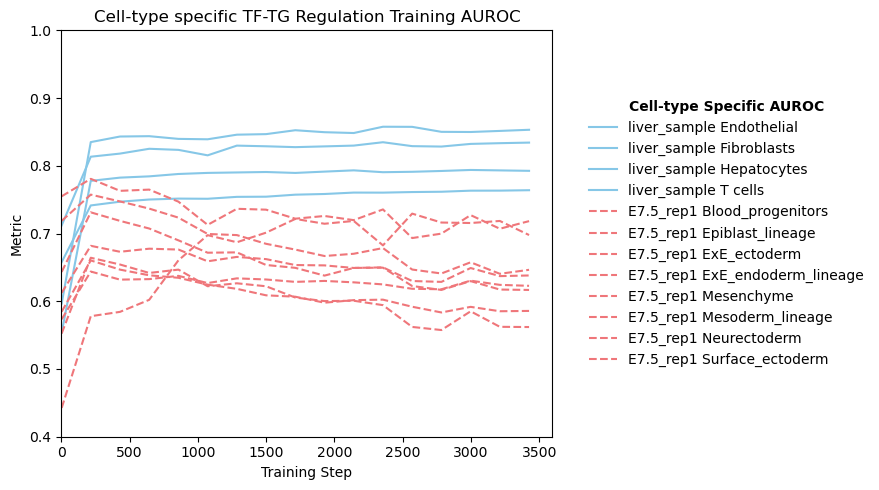

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(9, 5))

split = "val"

celltype_metric_name_map = {}
for tissue, sample in zip(sample_list["tissue"], sample_list["sample"]):
    split_celltypes = run.config[f"{tissue}__{sample}_{split}_celltypes"]
    
    split_metric_naming_convention = f"{split}/sample/{sample}/celltype/{{celltype}}/auroc"
    for celltype in split_celltypes:
        celltype_metric_name_map[(tissue, split, sample, celltype)] =  split_metric_naming_convention.format(celltype=celltype)

for (tissue, split, sample, celltype), metric_name in celltype_metric_name_map.items():
    metric_history = (
        run_history[["_step", metric_name]]
        .dropna()
        .sort_values("_step")
    )
    
    if f"{tissue}:{sample}" in holdout_samples or celltype in holdout_celltypes:
        color = "#EF767A"
        style = "--"
    else:
        color = "#86C7E7"
        style = "-"
    
    axes.plot(
        metric_history["_step"],
        metric_history[metric_name],
        label=f"{sample} {celltype}",
        color=color,
        linestyle=style,
    )

axes.set_title("Cell-type specific TF-TG Regulation Training AUROC")
axes.set_xlabel("Training Step")
axes.set_ylabel("Metric")
axes.set_ylim(0.4, 1)
axes.set_xlim(left=0)
axes.legend(
    bbox_to_anchor=(1.05, 0.5), 
    loc='center left',
    title="Cell-type Specific AUROC", 
    title_fontproperties={'weight': 'bold'}, 
    frameon=False
)

plt.tight_layout()

### Load Trained Model from Checkpoint

In [7]:
mdata = mu.read_h5mu(DATA_DIR / "processed/mouse_liver/liver_sample/multiome_processed.h5mu")
mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 19691 × 166431
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
  2 modalities
    rna:	19691 x 18960
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'donor', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'celltype_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'tsne', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	19691 x 147471
      obs:	'n_genes_by_counts', 'total_counts', 'outlier', 'n_counts', 'donor'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mean', 'std', 'nearest_gene', 'TSS_dist', 'TSS_dist_score'
      uns:	'log1p', 'lsi', 'neighbors', 'peak_gene_distance_params', 'peak_gene_links'
      obsm:	'X_lsi', 'X_lsi_harmony'
      varm:	'LSI'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In [8]:
import models.tf_to_tg_celltype as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module

def gpu_supports_torch_compile(device):
    if device.type != "cuda":
        return False

    major, minor = torch.cuda.get_device_capability(device)
    return major >= 7

def strip_compiled_prefix_from_state_dict(state_dict, prefix="_orig_mod."):
    """
    Remove torch.compile's _orig_mod prefix from state_dict keys.

    Examples:
        model._orig_mod.encoder.weight -> model.encoder.weight
        _orig_mod.encoder.weight       -> encoder.weight
    """
    cleaned = {}

    for key, value in state_dict.items():
        cleaned_key = key.replace(prefix, "")
        cleaned[cleaned_key] = value

    return cleaned

def load_tf_tg_regulation_model(
    tf_dna_model_path: Path,
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor,
    compile_model: bool = False,
    device: torch.device | None = None,
    model_module=None,
) -> tf_to_tg_module.LitTFTGRegulationModel:
    """
    model_module lets a caller load a checkpoint trained against a different
    TFTGRegulationModel definition than the default models.tf_to_tg -- e.g.
    models.tf_to_tg_testing while it is under active architecture changes there.
    Defaults to models.tf_to_tg (unchanged behaviour for every existing checkpoint).
    """
    model_module = model_module or tf_to_tg_module

    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if compile_model and not gpu_supports_torch_compile(device):
        if device.type == "cuda":
            major, minor = torch.cuda.get_device_capability(device)
            logging.warning(
                f"Skipping torch.compile because this GPU has compute capability "
                f"{major}.{minor}; Inductor/Triton requires >= 7.0."
            )
        else:
            logging.warning("Skipping torch.compile because device is not CUDA.")

        compile_model = False

    # -----------------------------
    # 1. Recreate base TF-DNA model uncompiled
    # -----------------------------
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # -----------------------------
    # 2. Load TF-DNA checkpoint
    # -----------------------------
    tf_dna_ckpt = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )

    tf_dna_state_dict = tf_dna_ckpt["state_dict"]

    if any("._orig_mod." in key or key.startswith("_orig_mod.") for key in tf_dna_state_dict):
        logging.info("Detected compiled TF-DNA checkpoint. Stripping _orig_mod prefixes.")
        tf_dna_state_dict = strip_compiled_prefix_from_state_dict(tf_dna_state_dict)

    lit_tf_dna_model = tf_to_dna_module.LitTFPeakBindingModel(
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    lit_tf_dna_model.load_state_dict(tf_dna_state_dict, strict=True)

    trained_tf_peak_model = lit_tf_dna_model.model
    trained_tf_peak_model.eval()

    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 3. Load TF-TG checkpoint
    # -----------------------------
    # load_from_checkpoint reconstructs the train-fitted expression and ATAC
    # scaler values from hyper_parameters. Loading only state_dict would silently
    # restore the default mean=0/std=1 because those scaler buffers are non-persistent.
    lit_tf_tg_model = model_module.LitTFTGRegulationModel.load_from_checkpoint(
        str(tf_tg_model_path), map_location="cpu",
    )
    lit_tf_tg_model.eval()

    for p in lit_tf_tg_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 5. Optional compile after loading
    # -----------------------------
    if compile_model:
        logging.info("Compiling loaded TF-TG core model.")
        lit_tf_tg_model.model = torch.compile(lit_tf_tg_model.model)

    # Evaluation needs the frozen TF-DNA model to recreate the binding scores.
    return lit_tf_tg_model, trained_tf_peak_model

In [9]:
species = "mm10"

mm10_tf_dna_path = CHKPT_DIR / "new_tf_dna_models" / "mm10_3831017_epoch_12.ckpt"
model_checkpoint = CHKPT_DIR / "celltype_tf_tg" / "celltype_joint_3881696_20260916_181748_296478" / "checkpoints" / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tf_dna_input_cache_dir = PROJECT_DIR / "cached_data" / species / "tf_dna_cache"
tf_embedding_cache_path = tf_dna_input_cache_dir / "tf_embeddings.pt"
tf_mask_cache_path = tf_dna_input_cache_dir / "tf_masks.pt"

tf_embeddings_tensor = torch.load(tf_embedding_cache_path, weights_only=True)
tf_mask_tensor = torch.load(tf_mask_cache_path, weights_only=True)

trained_model, trained_tf_peak_model = load_tf_tg_regulation_model(
    tf_dna_model_path=mm10_tf_dna_path,
    tf_tg_model_path=model_checkpoint,
    tf_embeddings_tensor= tf_embeddings_tensor,
    tf_mask_tensor= tf_mask_tensor,
    compile_model=False,
    device=device,
    model_module=tf_to_tg_module,
)

trained_model

LitTFTGRegulationModel(
  (model): SimpleTFTGRegulationModel(
    (peak_feature_proj): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): SiLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (tf_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_query_proj): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (peak_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (norm): Layer

### Load Trained Model Data

In [ ]:
def load_model_data(model_checkpoint: Path, split_name: str = "test"):
    """Load and concatenate every cached source used by a trained run."""
    logging.info(f"Loading model data for checkpoint {model_checkpoint} and split {split_name}")
    from torch.utils.data import ConcatDataset, DataLoader
    from scripts.train_tf_to_tg_celltype_model import (
        binding_score_cache_path,
        TFTGEdgeBagDataset,
    )

    def load_run_config(model_checkpoint: Path):
        run_dir = model_checkpoint.parent.parent
        with open(run_dir / "run_config.json") as handle:
            return json.load(handle)

    def source_specs(run_config):
        configured = run_config.get("dataset")
        if not configured:
            configured = [f"{run_config['tissue']}:{run_config['sample_name']}"]
        if isinstance(configured, str):
            configured = [configured]
        return [tuple(value.split(":", 1)) for value in configured]

    def load_multiome_data(run_config, tissue, sample_name):
        """
        Recreate the RNA and ATAC matrix order. 
        """
        
        eval_data_dir = Path(run_config["data_dir"])
        eval_mdata = mu.read(
            eval_data_dir / "processed" / tissue
            / sample_name / "multiome_processed.h5mu"
        )
        eval_rna = eval_mdata.mod["rna"]
        eval_atac = eval_mdata.mod["atac"]
        shared_cells = eval_rna.obs_names[eval_rna.obs_names.isin(eval_atac.obs_names)]
        eval_rna = eval_rna[shared_cells].copy()
        eval_atac = eval_atac[shared_cells].copy()

        max_autosome = 19 if run_config["species"] == "mm10" else 22
        valid_chroms = {f"chr{i}" for i in range(1, max_autosome + 1)}
        keep_peaks = np.array([
            peak.split(":", 1)[0] in valid_chroms for peak in eval_atac.var_names
        ])
        eval_atac = eval_atac[:, keep_peaks].copy()
        eval_rna.var_names = eval_rna.var_names.str.upper()
        
        return eval_rna, eval_atac

    def load_cell_pools(source_dir):
        with open(source_dir / "prepared_manifest.json") as handle:
            manifest = json.load(handle)
        cell_pools = {}
        with np.load(source_dir / "cell_pools.npz", allow_pickle=False) as archive:
            for pool in manifest["outputs"]["cell_pools"]:
                cell_pools[(pool["sample_id"], pool["cell_type"])] = (
                    archive[pool["array_key"]].astype(np.int64, copy=False)
                )
        return cell_pools

    def check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor):
        # Fail early if the source MuData has changed since training data preparation.
        rna_names = eval_rna.var_names.to_numpy()
        assert np.array_equal(
            rna_names[split_df["tf_rna_col"].to_numpy()], split_df["tf_name"].to_numpy()
        )
        assert np.array_equal(
            rna_names[split_df["tg_rna_col"].to_numpy()], split_df["tg_id"].to_numpy()
        )
        assert atac_mat.shape[1] == atac_peak_tensor.shape[0]

    def load_binding_scores(source_dir, split_df, run_config, tissue, sample_name):
        canonical_path = binding_score_cache_path(
            source_dir / "prepared", split_name, split_df,
            tf_dna_checkpoint=run_config["tf_dna_checkpoint"],
            max_peaks_per_tg=run_config["max_peaks_per_tg"],
        )
        config_key = f"{tissue}__{sample_name}_{split_name}_binding_cache"
        configured_path = Path(run_config.get(config_key, canonical_path))
        binding_path = canonical_path if canonical_path.exists() else configured_path
        if not binding_path.exists():
            raise FileNotFoundError(f"Binding scores not found at {binding_path}")
        binding_scores = torch.load(binding_path, map_location="cpu", weights_only=True)
        expected_shape = (len(split_df), run_config["max_peaks_per_tg"])
        if tuple(binding_scores.shape) != expected_shape:
            raise ValueError(
                f"{binding_path} has shape {tuple(binding_scores.shape)}; "
                f"expected {expected_shape}"
            )
        return binding_scores

    logging.info(f"  - Loading config")
    run_config = load_run_config(model_checkpoint)
    
    if split_name not in {"train", "val", "test"}:
        raise ValueError(f"Invalid split name: {split_name}")
    cache_dir = Path(run_config["cache_dir"])
    scaler_path = Path(run_config.get("input_scaler_path", cache_dir / "input_scaler.json"))
    with open(scaler_path) as handle:
        cached_scaler = json.load(handle)
    if cached_scaler != run_config.get("input_scaler"):
        raise ValueError("Cached scaler does not match this run's saved scaler")

    holdout_samples = set(run_config.get("holdout_sample", []))
    holdout_celltypes = set(run_config.get("holdout_celltype", []))
    dataset_parts = []
    source_edge_counts = {}
    for tissue, sample_name in source_specs(run_config):
        source_key = f"{tissue}__{sample_name}"
        
        if split_name == "train" and f"{tissue}:{sample_name}" in holdout_samples:
            logging.info(f"  - Skipping held-out training source {tissue}:{sample_name}")
            continue
        
        source_dir = cache_dir / "prepared_sources" / source_key
        
        if not source_dir.is_dir():
            raise FileNotFoundError(f"Prepared source cache not found: {source_dir}")

        logging.info(f"  - Loading {split_name} data for {tissue}:{sample_name}")
        
        split_df = pd.read_parquet(source_dir / f"edges_{split_name}.parquet")
        
        if split_name == "train" and holdout_celltypes:
            split_df = split_df.loc[
                ~split_df["cell_type"].isin(holdout_celltypes)
            ].reset_index(drop=True)
            
        if split_df.empty:
            continue

        atac_peak_tensor = torch.load(
            source_dir / "prepared" / sample_name / "atac_peak_tensor.pt",
            map_location="cpu", weights_only=True,
        )
        
        eval_rna, eval_atac = load_multiome_data(run_config, tissue, sample_name)
        
        rna_mat, atac_mat = eval_rna.X, eval_atac.X
        
        cell_pools = load_cell_pools(source_dir)
        
        check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor)
        
        split_binding_scores = load_binding_scores(
            source_dir, split_df, run_config, tissue, sample_name
        )
        
        dataset_parts.append(TFTGEdgeBagDataset(
            split_df,
            tf_embeddings_tensor=None, tf_mask_tensor=None,
            atac_peak_tensor=atac_peak_tensor, atac_mat=atac_mat, rna_mat=rna_mat,
            cell_pools=cell_pools,
            max_peaks_per_tg=run_config["max_peaks_per_tg"],
            resample_max_cells_per_pair=run_config["max_cells_per_pair"],
            resample_cells=False, binding_scores=split_binding_scores,
            seed=run_config["seed"],
        ))
        source_edge_counts[f"{tissue}:{sample_name}"] = len(split_df)

    if not dataset_parts:
        raise ValueError(f"No {split_name} datasets were available")
    split_dataset = (
        dataset_parts[0] if len(dataset_parts) == 1 else ConcatDataset(dataset_parts)
    )

    logging.info(f"  - Creating dataloader")
    split_dataloader = DataLoader(
        split_dataset, batch_size=run_config["batch_size"], shuffle=False,
        num_workers=run_config["num_workers"],
        persistent_workers=run_config["num_workers"] > 0,
        pin_memory=device.type == "cuda", drop_last=False,
    )
    
    print(
        f"Loaded {len(split_dataset):,} {split_name} edges from "
        f"{source_edge_counts} in {len(split_dataloader):,} batches. "
        "Inputs remain unscaled; the checkpoint model applies its saved scaler."
    )
    
    return split_dataset, split_dataloader, run_config

test_dataset, test_dataloader, test_run_config = load_model_data(
    model_checkpoint=model_checkpoint, split_name="test"
)

INFO:root:Loading model data for checkpoint /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3881696_20260916_181748_296478/checkpoints/last.ckpt and split test
INFO:root:  - Loading config
INFO:root:  - Loading test data for mouse_liver:liver_sample
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.se

Loaded 248,010 test edges from {'mouse_liver:liver_sample': 86667, 'mESC:E7.5_rep1': 161343} in 485 batches. Inputs remain unscaled; the checkpoint model applies its saved scaler.


### Evaluate own test set

In [ ]:
import torch.nn as nn
from tqdm import tqdm

def run_batch(trained_model, batch_cpu, train: bool, microbatch_size: int = 64):
    """One batch, microbatched. Returns (loss, edge_logits, labels), all on CPU."""
    B = len(batch_cpu["label"])
    
    gpu_keys = [
        "binding_score", "peak_accessibility", "peak_distance",
        "tf_expression", "tg_expression", "cell_mask", "peak_mask", "label",
    ]

    edge_parts, total_loss = [], 0.0
    for start in range(0, B, microbatch_size):
        end = min(start + microbatch_size, B)
        microbatch = {k: batch_cpu[k][start:end].to(device) for k in gpu_keys}

        with torch.set_grad_enabled(train):
            edge_logits, _ = trained_model(microbatch)
            loss = nn.functional.binary_cross_entropy_with_logits(
                edge_logits, microbatch["label"].float(), reduction="sum",
            ) / B

        if train:
            loss.backward()

        total_loss += loss.item()
        edge_parts.append(edge_logits.detach().cpu())
        del microbatch, edge_logits, loss

    return total_loss, torch.cat(edge_parts), batch_cpu["label"].float()


@torch.no_grad()
def evaluate(model, loader, desc="Evaluating"):
    model.eval()

    logits, labels = [], []
    loss_sum = 0.0
    n = 0

    progress = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        unit="batch",
        dynamic_ncols=True,
    )

    
    for batch_cpu in progress:
        b = len(batch_cpu["label"])

        # run_batch already manages gradient mode.
        loss, edge_logits, y = run_batch(
            model,
            batch_cpu,
            train=False,
        )

        # run_batch returns mean loss over this batch.
        loss_sum += loss * b
        n += b

        logits.append(edge_logits)
        labels.append(y)

        progress.set_postfix(
            loss=f"{loss_sum / n:.4f}",
            edges=n,
        )

    logits = torch.cat(logits)
    labels = torch.cat(labels)
    probabilities = logits.sigmoid()
    avg_loss = loss_sum / n

    if labels.min() != labels.max():
        auroc = roc_auc_score(
            labels.numpy(),
            probabilities.numpy(),
        )
    else:
        auroc = float("nan")

    return avg_loss, auroc, probabilities, labels

trained_model = trained_model.to(device)
eval_loss, eval_auroc, eval_probs, eval_labels = evaluate(trained_model, test_dataloader)


Evaluating: 100%|████████████████████████████████████████████████████████████████| 485/485 [07:30<00:00,  1.08batch/s, edges=248010, loss=0.5496]


In [23]:
inputs

,sample_id,cell_type,tf_name,tg_id,peak_ids,peak_distances,label,tf_embedding_idx,peak_atac_cols,tf_rna_col,tg_rna_col
0,liver_sample,Hepatocytes,FOXA2,GM36602,"[chr19:46658155-46659029, chr19:46659907-46660...","[3589.0, 5341.0, 7287.0, 7426.0, 8553.0, 11880...",False,252,"[72507, 72508, 72506, 72509, 72505, 72504, 725...",2195,18302
1,liver_sample,Fibroblasts,FOXA3,VWCE,"[chr19:10634601-10635278, chr19:10634107-10634...","[75.0, 869.0, 5615.0, 6949.0, 8198.0, 12827.0,...",True,229,"[69681, 69680, 69679, 69678, 69677, 69676, 696...",7043,17989
2,liver_sample,Hepatocytes,SETDB1,GM45871,"[chr18:90597830-90598683, chr18:90601575-90602...","[0.0, 1071.0, 10242.0, 17788.0, 56010.0, 73371...",True,320,"[68739, 68740, 68738, 68737, 68736, 68735, 687...",3071,17739
3,liver_sample,T cells,STAT1,RAB18,"[chr18:6764690-6765563, chr18:6734161-6735069,...","[0.0, 255.0, 3699.0, 10778.0, 17783.0, 27007.0...",True,418,"[64097, 64095, 64096, 64098, 64094, 64099, 641...",205,17254
4,liver_sample,Hepatocytes,CREB1,LZTS2,"[chr19:45006046-45006886, chr19:45005144-45005...","[0.0, 207.0, 921.0, 7964.0, 9056.0, 10713.0, 1...",True,109,"[72306, 72305, 72307, 72308, 72304, 72309, 723...",305,18264
...,...,...,...,...,...,...,...,...,...,...,...
248005,E7.5_rep1,Neurectoderm,NPAS3,BATF2,"[chr19:6184126-6185051, chr19:6182500-6183293,...","[5962.0, 7720.0, 8797.0, 11429.0, 15647.0, 210...",False,12,"[92737, 92736, 92735, 92738, 92734, 92739, 927...",12712,17504
248006,E7.5_rep1,Neurectoderm,NR3C1,SRA1,"[chr18:36802871-36803603, chr18:36801347-36802...","[0.0, 1075.0, 9005.0, 12543.0, 19540.0, 36593....",False,438,"[88002, 88001, 88000, 87999, 87998, 87997, 879...",17108,17058
248007,E7.5_rep1,Blood_progenitors,TCF3,GM5820,"[chr18:39024604-39025329, chr18:39027834-39028...","[182.0, 2063.0, 2400.0, 13156.0, 15326.0, 1867...",False,26,"[88319, 88320, 88330, 88321, 88318, 88322, 883...",10676,17105
248008,E7.5_rep1,Blood_progenitors,GATA2,ACY3,"[chr19:4037475-4038402, chr19:4034418-4035264,...","[271.0, 1306.0, 2340.0, 3348.0, 4596.0, 5801.0...",False,255,"[92340, 92339, 92338, 92337, 92341, 92342, 923...",6286,17390


In [24]:
inputs = pd.concat([ds.inputs for ds in test_dataset.datasets], ignore_index=True)
test_set_predictions = inputs[[
    "sample_id", "cell_type", "tf_name", "tg_id", "label"
]].copy()
test_set_predictions["probability"] = eval_probs.numpy()
test_set_predictions["predicted_label"] = (
    test_set_predictions["probability"] >= 0.5
).astype(np.int8)

grn_columns = ["SampleID", "CellType", "Source", "Target", "Score", "Label"]
evaluation_grn = (
    test_set_predictions
    .rename(columns={
        "sample_id": "SampleID",
        "cell_type": "CellType",
        "tf_name": "Source",
        "tg_id": "Target",
        "probability": "Score",
        "label": "Label"
    })
    .loc[:, grn_columns]
    .assign(
        Source=lambda frame: frame["Source"].astype(str).str.upper(),
        Target=lambda frame: frame["Target"].astype(str).str.upper(),
    )
)

display(evaluation_grn.head())

,SampleID,CellType,Source,Target,Score,Label
0,liver_sample,Hepatocytes,FOXA2,GM36602,0.568570,False
1,liver_sample,Fibroblasts,FOXA3,VWCE,0.001707,True
2,liver_sample,Hepatocytes,SETDB1,GM45871,0.030800,True
3,liver_sample,T cells,STAT1,RAB18,0.824767,True
4,liver_sample,Hepatocytes,CREB1,LZTS2,0.834209,True


### Load Other Method Cell Type Specific GRNs and label

In [14]:
from pathlib import Path

import pandas as pd


other_method_grn_dir = Path(
    "/gpfs/Labs/Uzun/DATA/PROJECTS/"
    "2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/"
    "other_method_celltype_grns"
)

cell_type_specific_gt_dir = (
    DATA_DIR / "ground_truth_files" / "cell_type_specific"
)
species_gt_dir = cell_type_specific_gt_dir / species


# ---------------------------------------------------------
# INDEX FILES ONCE
# This is particularly useful on GPFS, where repeated rglob
# calls can be relatively expensive.
# ---------------------------------------------------------
method_dirs = sorted(
    path for path in other_method_grn_dir.iterdir()
    if path.is_dir()
)

method_file_index = {
    method_dir.name: list(method_dir.rglob("*.tsv"))
    for method_dir in method_dirs
}

gt_file_index = {
    path.name: path
    for path in species_gt_dir.rglob("*_ground_truth.parquet")
}


# ---------------------------------------------------------
# LOAD EACH CELL-TYPE GROUND TRUTH ONLY ONCE
# ---------------------------------------------------------
gt_cache = {}
method_grns = {}

celltypes = evaluation_grn["CellType"].dropna().unique()

for celltype in celltypes:
    print(celltype)
    celltype_file_name = celltype.replace(" ", "_")

    gt_filename = f"{celltype_file_name}_ground_truth.parquet"
    gt_path = gt_file_index.get(gt_filename)

    if gt_path is None:
        print(f"No ground truth found for {celltype}")
        continue

    # Load and prepare this cell type's GT once.
    gt = pd.read_parquet(
        gt_path,
        columns=["Source", "Target"],
    )

    gt = (
        gt.assign(
            Source=gt["Source"].astype(str).str.upper(),
            Target=gt["Target"].astype(str).str.upper(),
        )
        .drop_duplicates(["Source", "Target"])
    )

    gt_sources = set(gt["Source"])
    gt_targets = set(gt["Target"])

    # A vectorized edge lookup index.
    gt_edge_index = pd.MultiIndex.from_frame(
        gt[["Source", "Target"]]
    )

    gt_cache[celltype] = {
        "path": gt_path,
        "sources": gt_sources,
        "targets": gt_targets,
        "edges": gt_edge_index,
    }

    for method_dir in method_dirs:
        method_name = method_dir.name
        filename_prefix = (
            f"{method_name.lower().replace('_', '')}_{celltype_file_name}_"
        )

        matching_paths = [
            path
            for path in method_file_index[method_name]
            if path.name.lower().startswith(filename_prefix.lower())
        ]

        if not matching_paths:
            continue

        if len(matching_paths) > 1:
            print(
                f"Warning: found {len(matching_paths)} files for "
                f"{method_name}, {celltype}; using {matching_paths[0]}"
            )

        method_grn_path = sorted(matching_paths)[0]

        # Read only required columns.
        other_method_grn = pd.read_csv(
            method_grn_path,
            sep="\t",
            usecols=["Source", "Target", "Score"],
        )
        
        # For methods that report multiple scores for the same TF-TG pair, take the mean score.
        other_method_grn = other_method_grn.groupby(["Source", "Target"]).agg({"Score": "mean"}).reset_index()

        other_method_grn["Source"] = (
            other_method_grn["Source"].astype(str).str.upper()
        )
        other_method_grn["Target"] = (
            other_method_grn["Target"].astype(str).str.upper()
        )

        # Restrict evaluation to TFs and TGs represented in the GT.
        source_mask = other_method_grn["Source"].isin(gt_sources)
        target_mask = other_method_grn["Target"].isin(gt_targets)

        matching_tfs = other_method_grn.loc[
            source_mask, "Source"
        ].nunique()

        matching_tgs = other_method_grn.loc[
            target_mask, "Target"
        ].nunique()

        print(
            f"  - {method_name}: {matching_tfs:,} TFs | {matching_tgs:,} TGs matching ground truth"
        )

        other_method_grn = (
            other_method_grn.loc[
                source_mask & target_mask,
                ["Source", "Target", "Score"],
            ]
            .copy()
        )

        # Vectorized edge labeling.
        predicted_edge_index = pd.MultiIndex.from_frame(
            other_method_grn[["Source", "Target"]]
        )

        other_method_grn["Label"] = (
            predicted_edge_index.isin(gt_edge_index).astype("int8")
        )

        other_method_grn.insert(0, "CellType", celltype)

        method_grns[(method_name, celltype)] = other_method_grn


print(f"Loaded {len(method_grns)} method/cell-type GRNs")

display(
    method_grns[("CellOracle", "Hepatocytes")].head()
)

Hepatocytes


  - CellOracle: 21 TFs | 11,153 TGs matching ground truth
  - FigR: 20 TFs | 7,718 TGs matching ground truth
  - LINGER: 20 TFs | 14,998 TGs matching ground truth
  - Pando: 12 TFs | 3,165 TGs matching ground truth
  - SCENIC_PLUS: 8 TFs | 4,126 TGs matching ground truth
Fibroblasts
  - CellOracle: 17 TFs | 10,712 TGs matching ground truth
  - FigR: 17 TFs | 6,373 TGs matching ground truth
  - LINGER: 17 TFs | 11,656 TGs matching ground truth
  - Pando: 17 TFs | 6,161 TGs matching ground truth
  - SCENIC_PLUS: 4 TFs | 4,588 TGs matching ground truth
T cells
  - CellOracle: 47 TFs | 10,123 TGs matching ground truth
  - FigR: 47 TFs | 4,562 TGs matching ground truth
  - LINGER: 42 TFs | 9,740 TGs matching ground truth
  - Pando: 47 TFs | 6,479 TGs matching ground truth
  - SCENIC_PLUS: 3 TFs | 3,923 TGs matching ground truth
Endothelial
  - CellOracle: 6 TFs | 8,458 TGs matching ground truth
  - FigR: 6 TFs | 5,313 TGs matching ground truth
  - LINGER: 6 TFs | 9,622 TGs matching ground t

,CellType,Source,Target,Score,Label
4023,Hepatocytes,ARID2,1300002E11RIK,0.004140,0
4027,Hepatocytes,ARID2,1700001L05RIK,0.001373,0
4028,Hepatocytes,ARID2,1700003E16RIK,0.003063,0
4033,Hepatocytes,ARID2,1700042O10RIK,0.036719,0
4034,Hepatocytes,ARID2,1700065D16RIK,0.000171,0


## Cross-trained model vs other inference methods

In [ ]:
# Use the same method name and colors as test_tf_tg_predictions.ipynb.
SELF_MODEL_METHOD = "TF-TG Model (self-trained)"
CROSS_MODEL_METHOD = "TF-TG Model (cross-trained)"

method_display_name_map = {
    SELF_MODEL_METHOD: "MONICA-STM",
    CROSS_MODEL_METHOD: "MONICA-CTM",
}

method_color_dict = {
    SELF_MODEL_METHOD: "#4195df",
    CROSS_MODEL_METHOD: "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
    "GRaNIE": "#F98637",
}

metric_name_map = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "early_precision": "Early Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
}

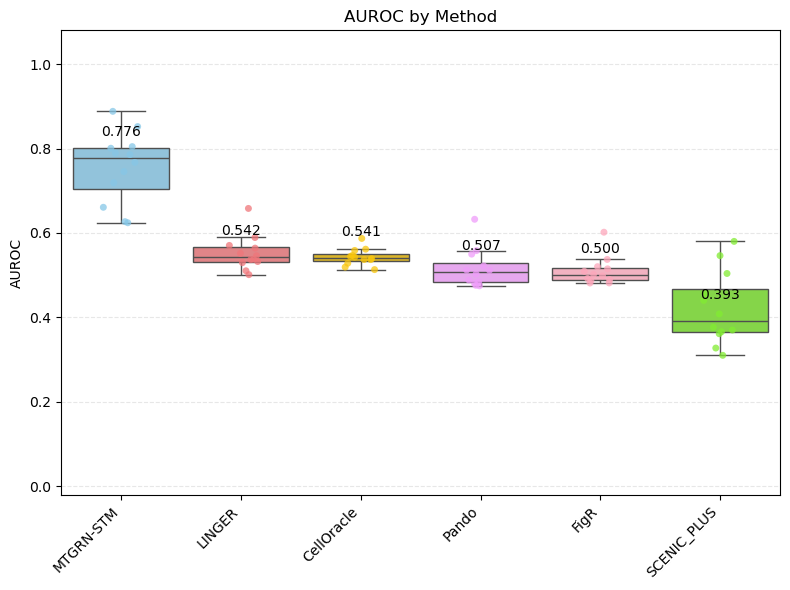

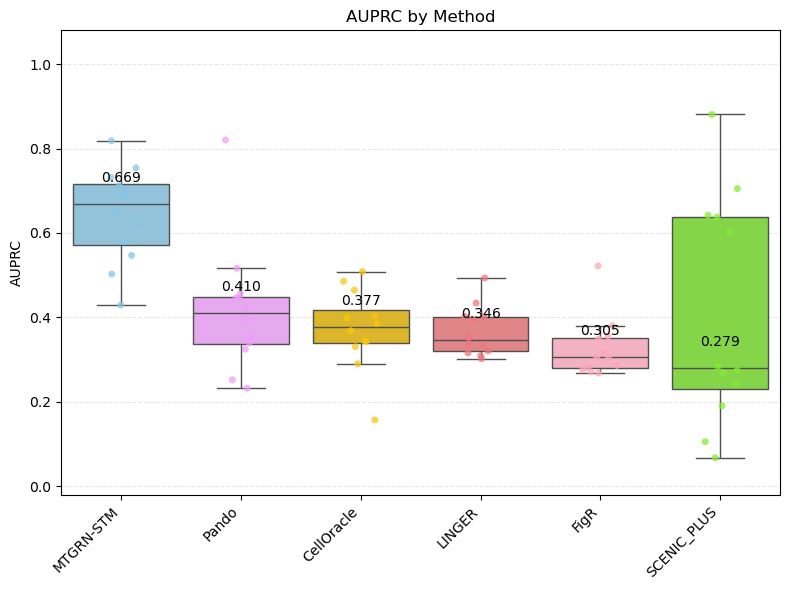

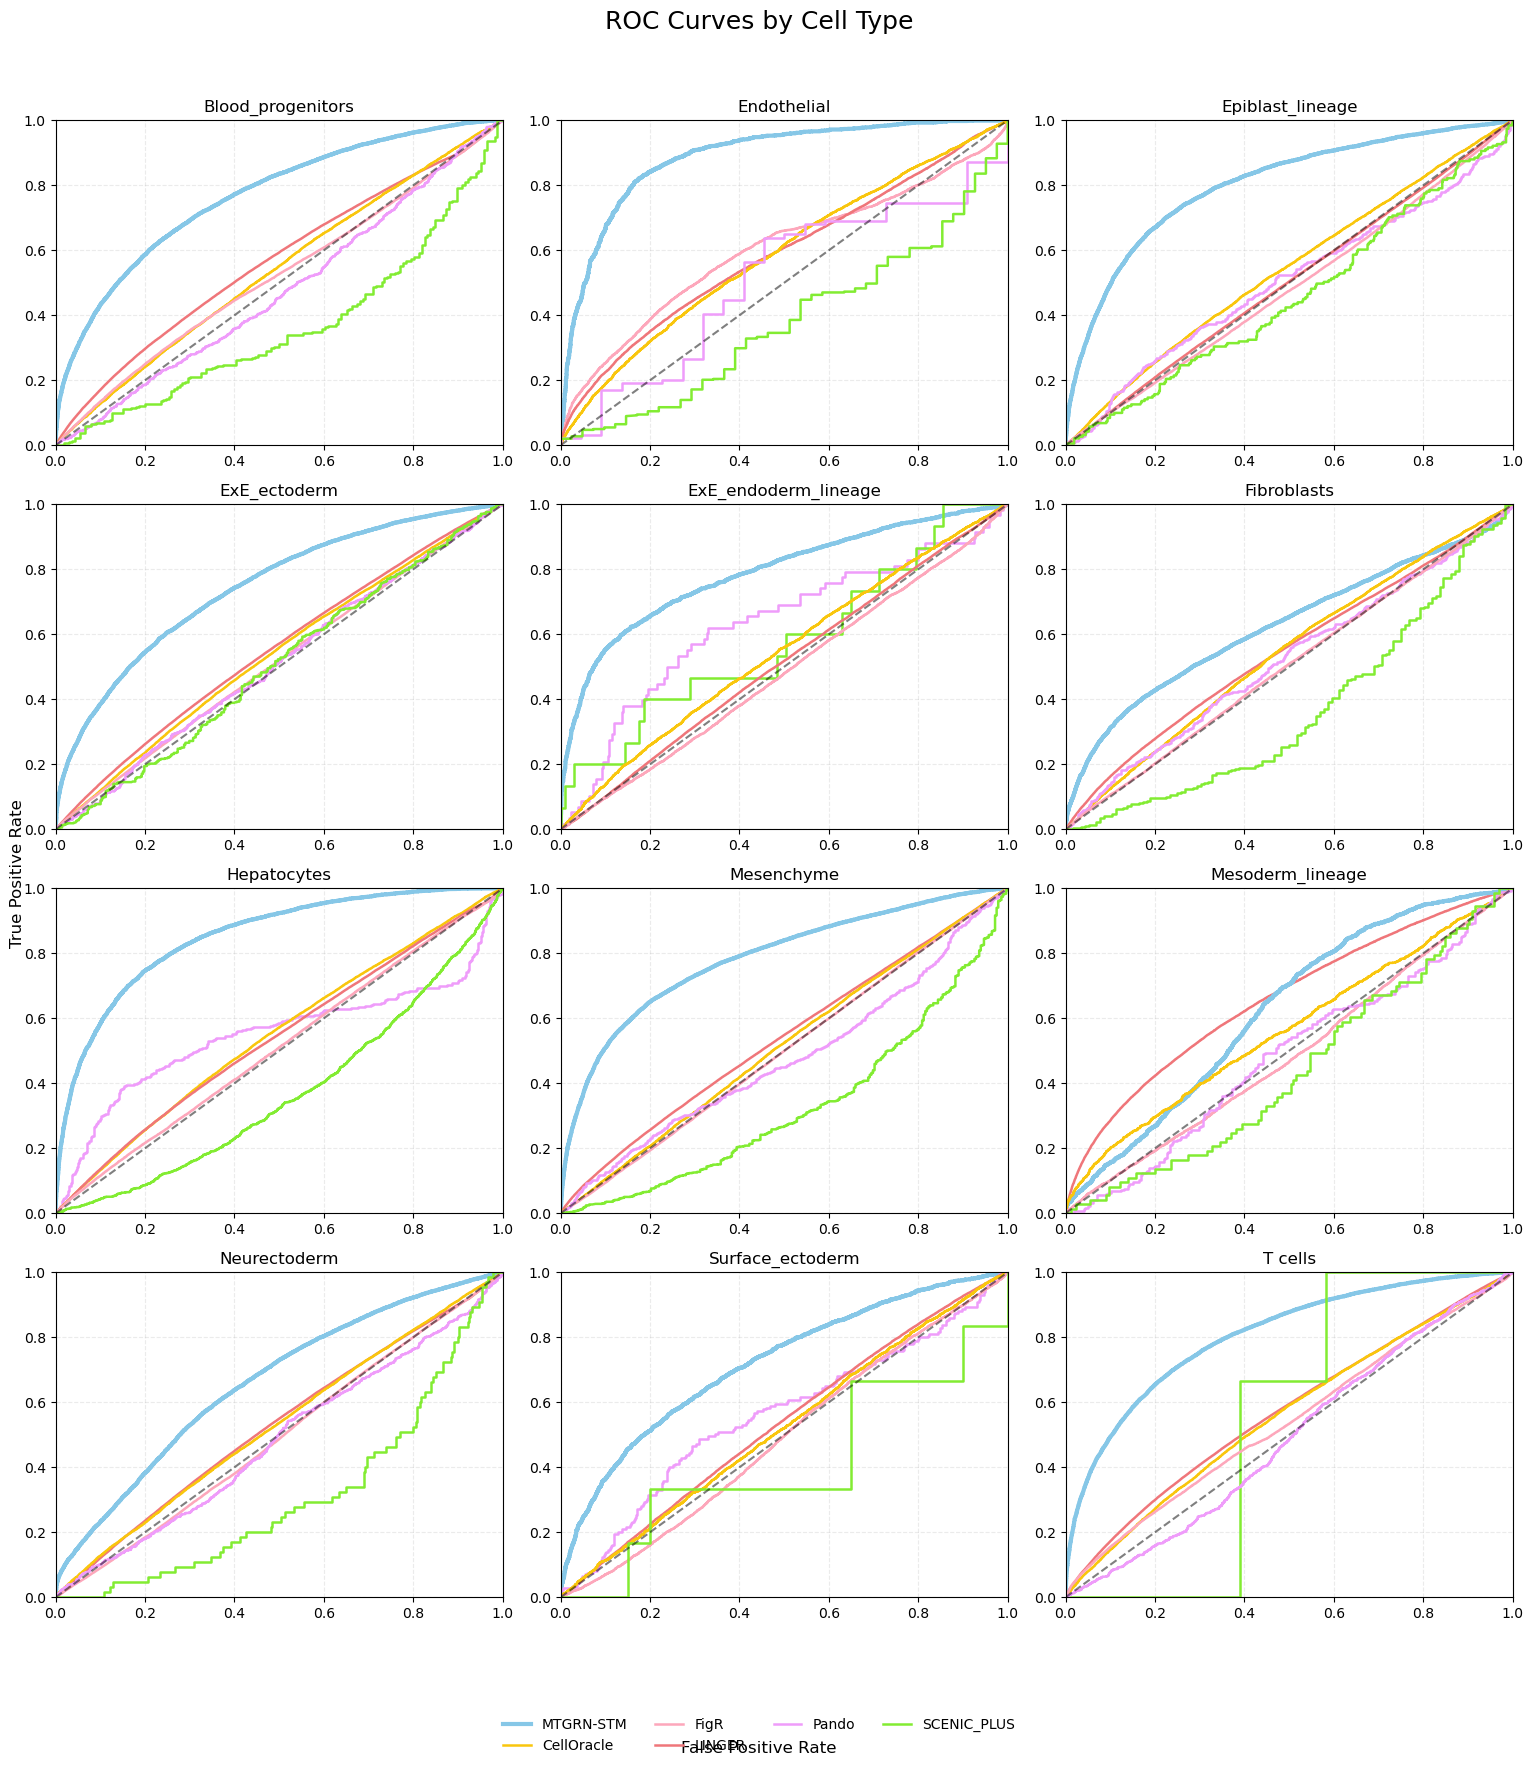

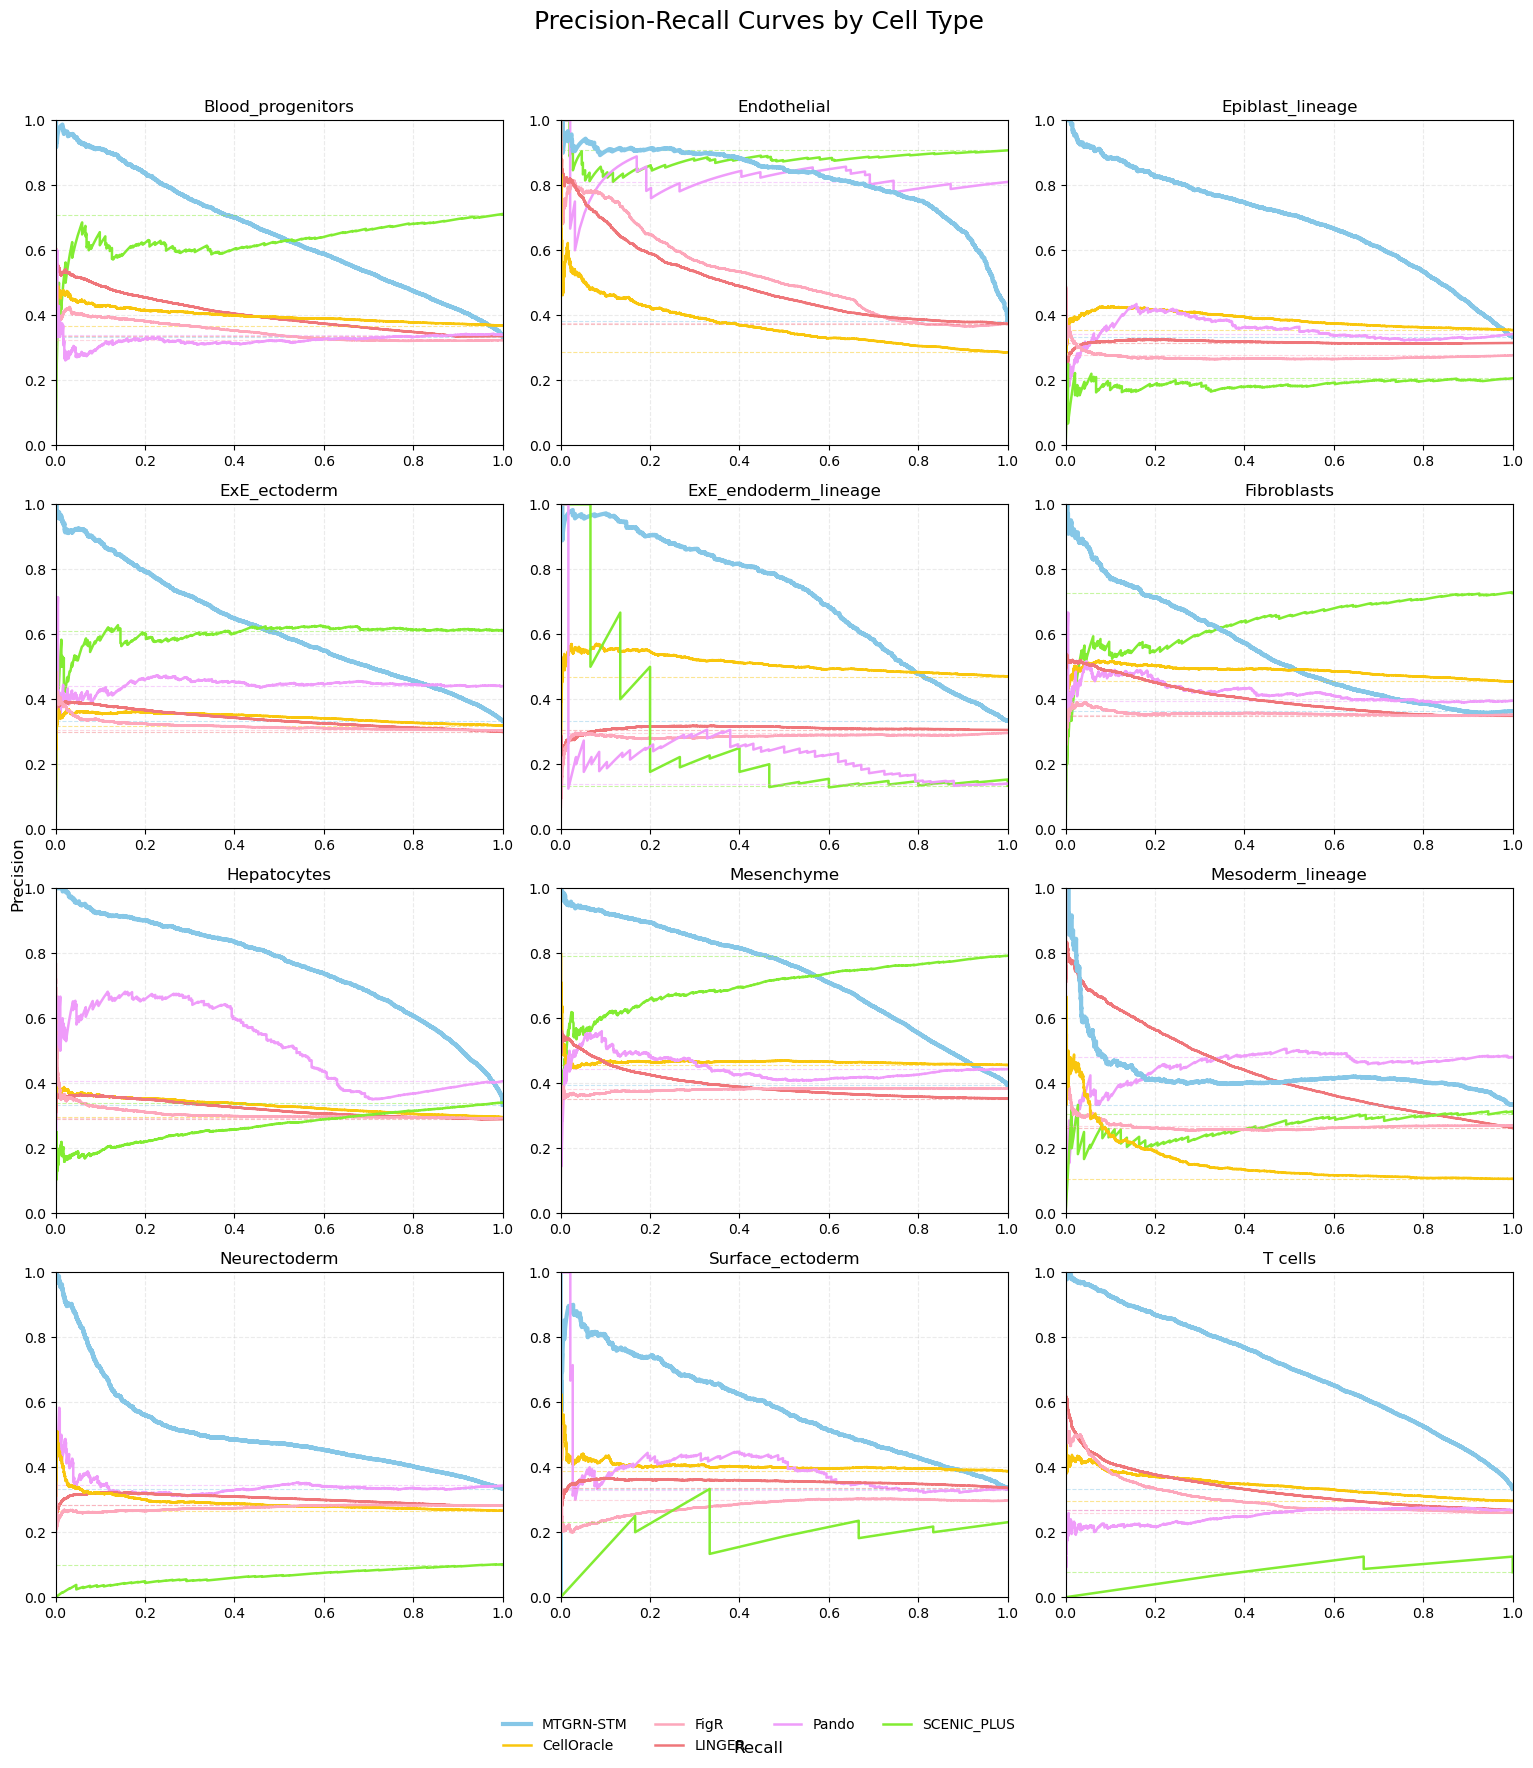

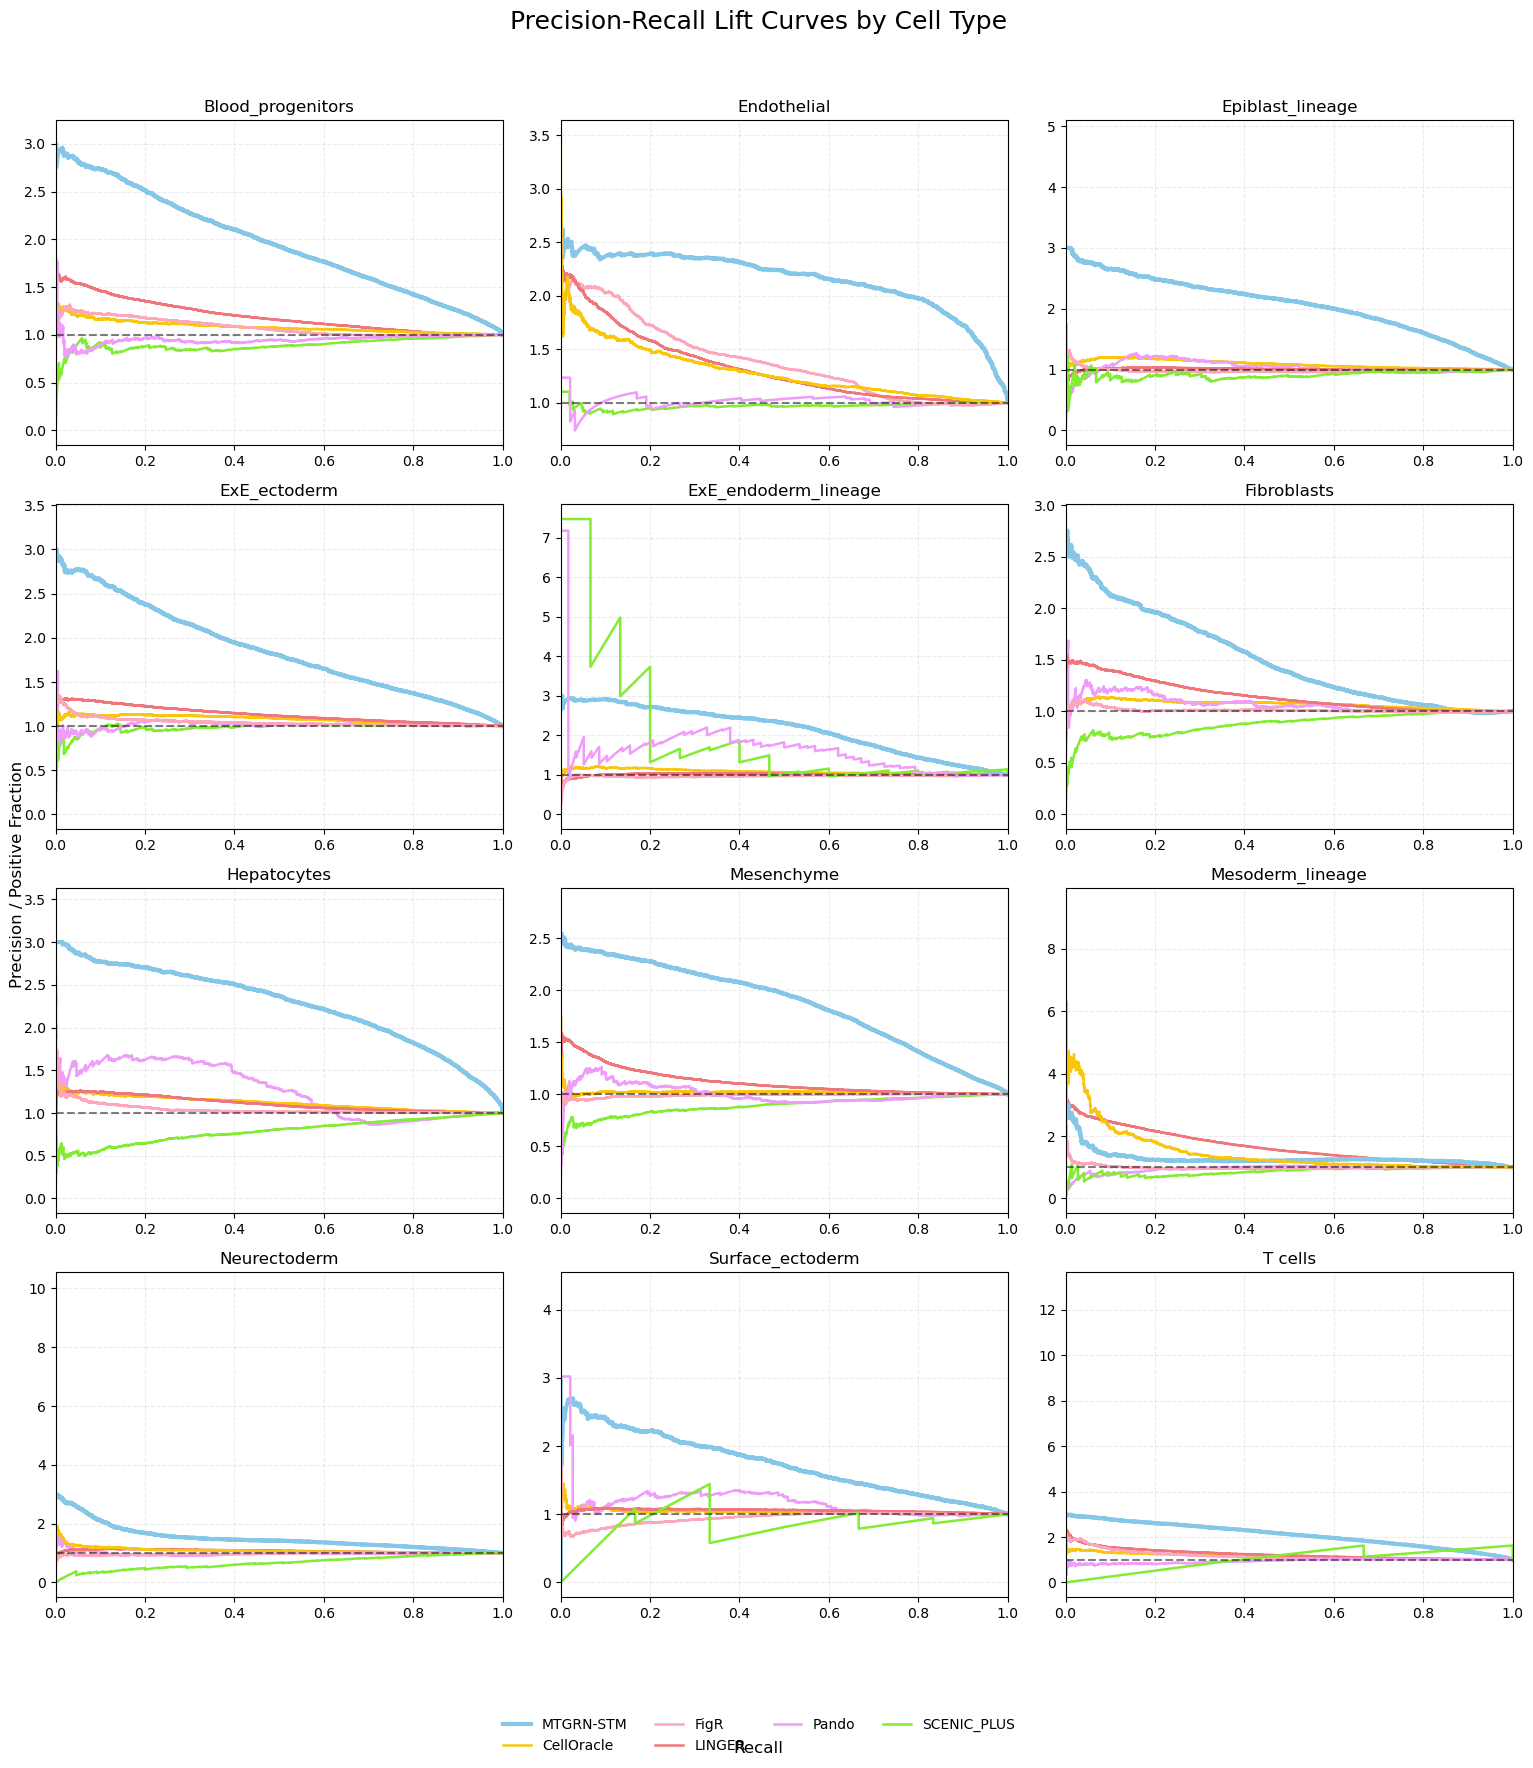

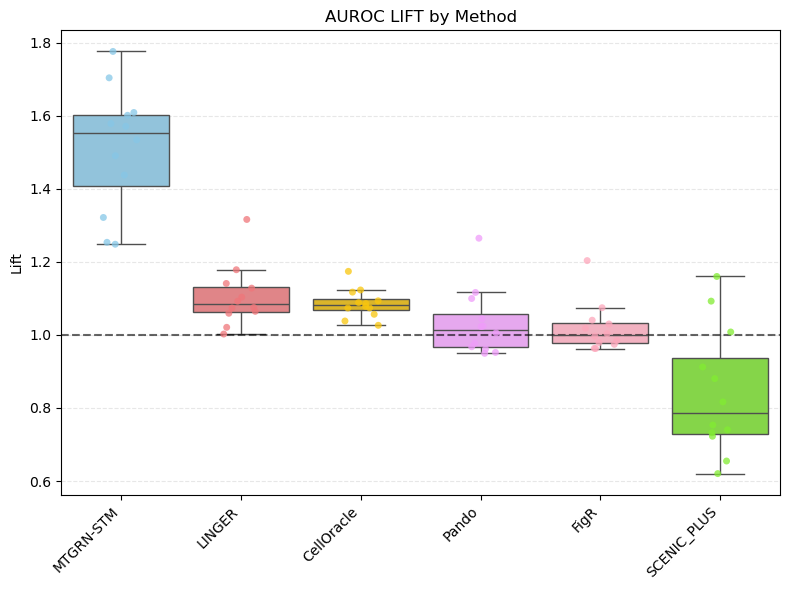

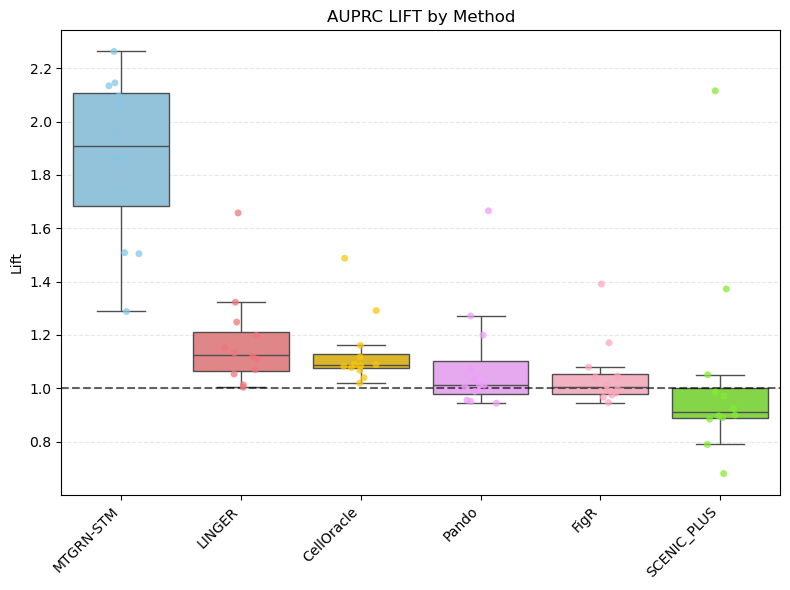

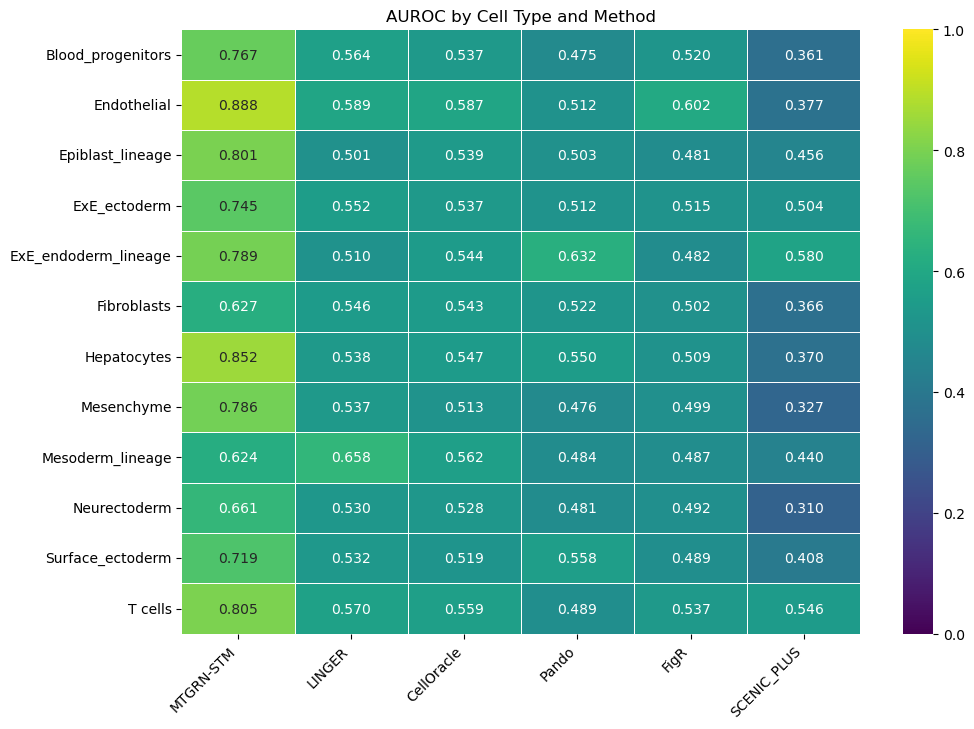

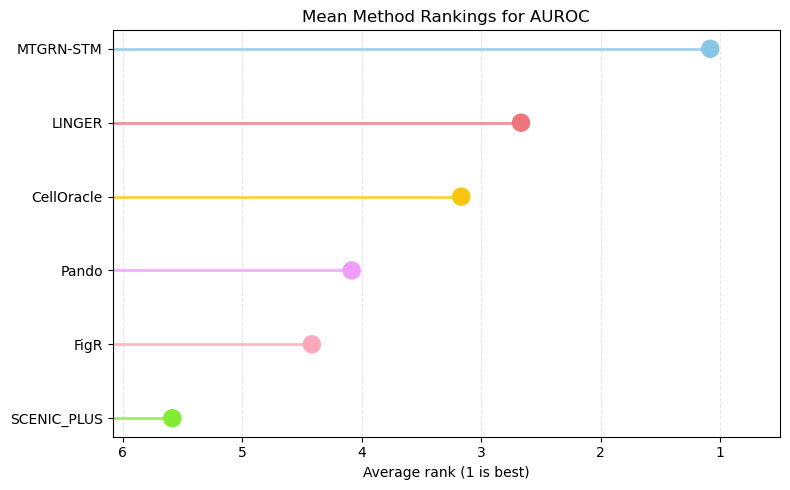

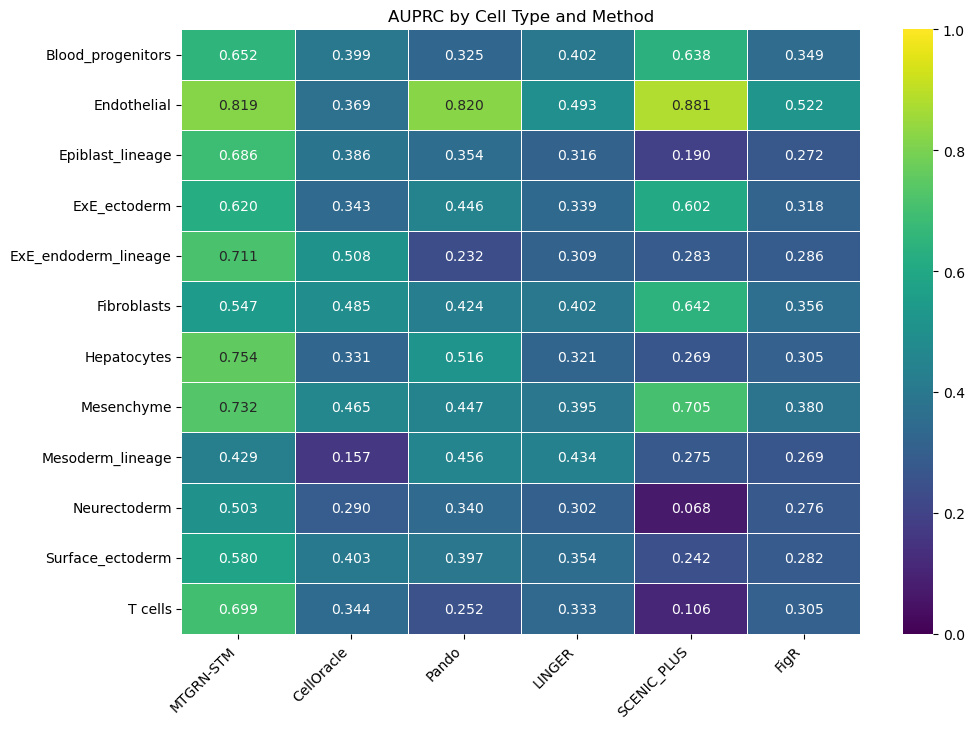

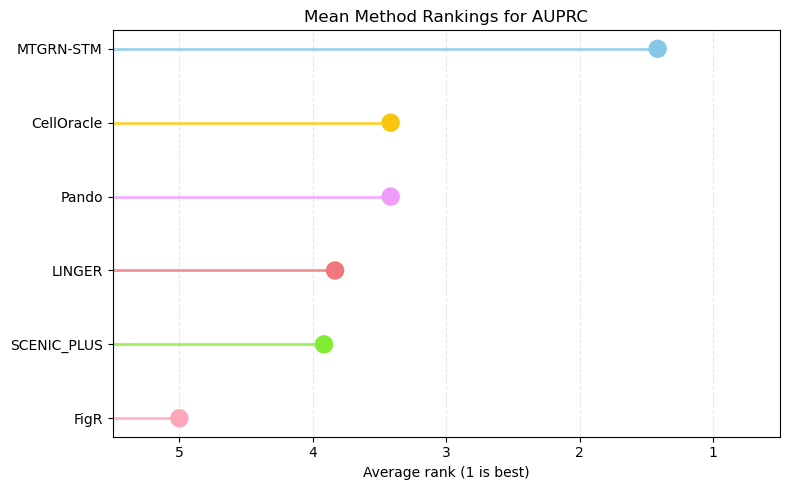

,method_name,cell_type,n_edges,positive_fraction,auroc,rand_auroc,auroc_lift,auprc,rand_auprc,auprc_lift
0,TF-TG Model (self-trained),Blood_progenitors,29487,0.333333,0.767136,0.5,1.534272,0.651953,0.333333,1.955859
1,LINGER,Blood_progenitors,299806,0.335817,0.564087,0.5,1.128174,0.402225,0.335817,1.197751
2,CellOracle,Blood_progenitors,32761,0.367876,0.537024,0.5,1.074048,0.398826,0.367876,1.084129
3,FigR,Blood_progenitors,86910,0.323427,0.520180,0.5,1.040361,0.349001,0.323427,1.079074
4,Pando,Blood_progenitors,2431,0.339778,0.474815,0.5,0.949631,0.324592,0.339778,0.955307
...,...,...,...,...,...,...,...,...,...,...
67,LINGER,T cells,409080,0.267148,0.570487,0.5,1.140973,0.333414,0.267148,1.248050
68,CellOracle,T cells,44782,0.296391,0.558648,0.5,1.117295,0.343995,0.296391,1.160610
69,SCENIC_PLUS,T cells,39,0.076923,0.546296,0.5,1.092593,0.105556,0.076923,1.372222
70,FigR,T cells,98229,0.260687,0.537285,0.5,1.074571,0.305124,0.260687,1.170462


Saved comparison plots and metrics to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3881696_20260916_181748_296478/self_trained_method_comparison_plots


In [ ]:
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

comparison_plot_dir = (
    model_checkpoint.parent.parent / "self_trained_method_comparison_plots"
)
comparison_plot_dir.mkdir(parents=True, exist_ok=True)

# method_grns contains the external methods. Add the evaluated TF-TG model,
# keeping one DataFrame per (method, cell type). Each method is scored over the
# labeled edge set already prepared above; unscored edges are not zero-filled.
comparison_grns = {
    key: frame.copy() for key, frame in method_grns.items()
}
for cell_type, frame in evaluation_grn.groupby("CellType", sort=True):
    comparison_grns[(SELF_MODEL_METHOD, cell_type)] = frame.copy()

available_methods = sorted({method for method, _ in comparison_grns})
method_order = (
    ([SELF_MODEL_METHOD] if SELF_MODEL_METHOD in available_methods else [])
    + [method for method in available_methods if method != SELF_MODEL_METHOD]
)
fallback_colors = sns.color_palette("tab10", n_colors=max(len(method_order), 1))
for index, method in enumerate(method_order):
    method_color_dict.setdefault(method, fallback_colors[index])

comparison_frames = {}
metric_rows = []
for (method_name, cell_type), frame in sorted(comparison_grns.items()):
    required = {"Score", "Label"}
    missing = required - set(frame.columns)
    if missing:
        logging.warning(
            "Skipping %s / %s; missing columns: %s",
            method_name, cell_type, sorted(missing),
        )
        continue

    clean = frame.copy()
    clean["Score"] = pd.to_numeric(clean["Score"], errors="coerce")
    clean["Label"] = pd.to_numeric(clean["Label"], errors="coerce")
    clean = clean.dropna(subset=["Score", "Label"]).copy()
    clean["Label"] = clean["Label"].astype(np.int8)

    if clean.empty or clean["Label"].nunique() < 2:
        logging.warning(
            "Skipping %s / %s; both label classes are required",
            method_name, cell_type,
        )
        continue

    labels = clean["Label"].to_numpy()
    scores = clean["Score"].to_numpy(dtype=float)
    auroc = roc_auc_score(labels, scores)
    auprc = average_precision_score(labels, scores)
    positive_fraction = float(labels.mean())

    comparison_frames[(method_name, cell_type)] = clean
    metric_rows.append({
        "method_name": method_name,
        "cell_type": cell_type,
        "n_edges": len(clean),
        "positive_fraction": positive_fraction,
        "auroc": auroc,
        "rand_auroc": 0.5,
        "auroc_lift": auroc / 0.5,
        "auprc": auprc,
        "rand_auprc": positive_fraction,
        "auprc_lift": auprc / positive_fraction,
    })

comparison_metric_df = pd.DataFrame(metric_rows)
if comparison_metric_df.empty:
    raise ValueError("No method/cell-type comparisons have both label classes")

all_comparison_figures = {}


def _display_method_name(method_name):
    return method_display_name_map.get(method_name, method_name)


def plot_method_metric_boxplot(metric_name):
    plot_df = comparison_metric_df.dropna(subset=[metric_name]).copy()
    order = (
        plot_df.groupby("method_name")[metric_name]
        .median().sort_values(ascending=False).index.tolist()
    )
    palette = {method: method_color_dict[method] for method in order}
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        data=plot_df, x="method_name", y=metric_name,
        hue="method_name", order=order, hue_order=order,
        palette=palette, showfliers=False, legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_df, x="method_name", y=metric_name,
        hue="method_name", order=order, hue_order=order,
        palette=palette, dodge=False, jitter=0.15, alpha=0.75,
        size=5, legend=False, ax=ax,
    )
    for position, method in enumerate(order):
        median = plot_df.loc[plot_df["method_name"] == method, metric_name].median()
        ax.text(position, min(median + 0.045, 1.05), f"{median:.3f}",
                ha="center", va="bottom", fontsize=10)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        [_display_method_name(method) for method in order],
        rotation=45, ha="right",
    )
    ax.set_ylim(-0.02, 1.08)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name.upper())
    ax.set_title(f"{metric_name.upper()} by Method")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return fig, ax


for metric_name in ("auroc", "auprc"):
    fig, ax = plot_method_metric_boxplot(metric_name)
    fig.savefig(
        comparison_plot_dir / f"{metric_name}_by_method_boxplot.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    all_comparison_figures[f"{metric_name}_boxplot"] = (fig, ax)
    plt.show()


def plot_cell_type_curve_panels(curve_kind, ncols=3):
    cell_types = sorted(comparison_metric_df["cell_type"].unique())
    nrows = math.ceil(len(cell_types) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 4.5 * nrows), squeeze=False,
    )

    for ax, cell_type in zip(axes.flat, cell_types):
        cell_metrics = comparison_metric_df[
            comparison_metric_df["cell_type"] == cell_type
        ]
        metric_column = "auroc" if curve_kind == "roc" else "auprc"
        plotted_methods = (
            cell_metrics.sort_values(metric_column, ascending=False)["method_name"]
            .tolist()
        )
        for method_name in plotted_methods:
            clean = comparison_frames[(method_name, cell_type)]
            labels = clean["Label"].to_numpy()
            scores = clean["Score"].to_numpy(dtype=float)
            color = method_color_dict[method_name]
            linewidth = 3 if method_name == SELF_MODEL_METHOD else 1.8

            if curve_kind == "roc":
                x_values, y_values, _ = roc_curve(labels, scores)
            else:
                precision, recall, _ = precision_recall_curve(labels, scores)
                x_values = recall
                if curve_kind == "prc_lift":
                    y_values = precision / max(float(labels.mean()), 1e-12)
                else:
                    y_values = precision

            ax.plot(x_values, y_values, color=color, linewidth=linewidth)
            if curve_kind == "prc":
                ax.axhline(
                    float(labels.mean()), color=color, linestyle="--",
                    linewidth=0.8, alpha=0.45,
                )

        if curve_kind == "roc":
            ax.plot([0, 1], [0, 1], color="black", linestyle="--", alpha=0.5)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        elif curve_kind == "prc":
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            ax.axhline(1, color="black", linestyle="--", alpha=0.5)
            ax.set_xlim(0, 1)

        ax.set_title(cell_type)
        ax.grid(linestyle="--", alpha=0.25)

    for ax in axes.flat[len(cell_types):]:
        ax.set_visible(False)

    title_by_kind = {
        "roc": "ROC Curves by Cell Type",
        "prc": "Precision-Recall Curves by Cell Type",
        "prc_lift": "Precision-Recall Lift Curves by Cell Type",
    }
    y_label_by_kind = {
        "roc": "True Positive Rate",
        "prc": "Precision",
        "prc_lift": "Precision / Positive Fraction",
    }
    fig.suptitle(title_by_kind[curve_kind], fontsize=18)
    fig.supxlabel("False Positive Rate" if curve_kind == "roc" else "Recall")
    fig.supylabel(y_label_by_kind[curve_kind])

    legend_handles = [
        Line2D(
            [0], [0], color=method_color_dict[method],
            linewidth=3 if method == SELF_MODEL_METHOD else 1.8,
            label=_display_method_name(method),
        )
        for method in method_order
        if method in set(comparison_metric_df["method_name"])
    ]
    fig.legend(
        handles=legend_handles, loc="lower center", ncol=min(4, len(legend_handles)),
        bbox_to_anchor=(0.5, 0.005), frameon=False,
    )
    fig.tight_layout(rect=(0, 0.06, 1, 0.96))
    return fig, axes


for curve_kind in ("roc", "prc", "prc_lift"):
    fig, axes = plot_cell_type_curve_panels(curve_kind)
    fig.savefig(
        comparison_plot_dir / f"{curve_kind}_curves_by_cell_type.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    all_comparison_figures[f"{curve_kind}_curves"] = (fig, axes)
    plt.show()


def plot_lift_boxplot(lift_column):
    plot_df = comparison_metric_df.dropna(subset=[lift_column]).copy()
    order = (
        plot_df.groupby("method_name")[lift_column]
        .median().sort_values(ascending=False).index.tolist()
    )
    palette = {method: method_color_dict[method] for method in order}
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        data=plot_df, x="method_name", y=lift_column,
        hue="method_name", order=order, hue_order=order,
        palette=palette, showfliers=False, legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_df, x="method_name", y=lift_column,
        hue="method_name", order=order, hue_order=order,
        palette=palette, dodge=False, jitter=0.15, alpha=0.75,
        size=5, legend=False, ax=ax,
    )
    ax.axhline(1, color="black", linestyle="--", alpha=0.6)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        [_display_method_name(method) for method in order],
        rotation=45, ha="right",
    )
    ax.set_xlabel("")
    ax.set_ylabel("Lift")
    ax.set_title(f"{lift_column.replace('_', ' ').upper()} by Method")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return fig, ax


for lift_column in ("auroc_lift", "auprc_lift"):
    fig, ax = plot_lift_boxplot(lift_column)
    fig.savefig(
        comparison_plot_dir / f"{lift_column}_by_method_boxplot.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    all_comparison_figures[f"{lift_column}_boxplot"] = (fig, ax)
    plt.show()


rank_summary = {}
for metric_name in ("auroc", "auprc"):
    rank_df = comparison_metric_df[["cell_type", "method_name", metric_name]].dropna().copy()
    rank_df["rank"] = (
        rank_df.groupby("cell_type")[metric_name]
        .rank(method="min", ascending=False)
    )
    average_rank = (
        rank_df.groupby("method_name", as_index=False)["rank"]
        .mean().rename(columns={"rank": "average_rank"})
        .sort_values("average_rank")
    )
    ordered_methods = average_rank["method_name"].tolist()

    metric_matrix = rank_df.pivot(
        index="cell_type", columns="method_name", values=metric_name,
    ).reindex(columns=ordered_methods)
    fig_heatmap, ax_heatmap = plt.subplots(
        figsize=(1.25 * len(ordered_methods) + 3, 0.45 * len(metric_matrix) + 2),
    )
    sns.heatmap(
        metric_matrix, annot=True, fmt=".3f", cmap="viridis",
        vmin=0, vmax=1, linewidths=0.5, linecolor="white", ax=ax_heatmap,
    )
    ax_heatmap.set_xticklabels(
        [_display_method_name(method) for method in ordered_methods],
        rotation=45, ha="right",
    )
    ax_heatmap.set_xlabel("")
    ax_heatmap.set_ylabel("")
    ax_heatmap.set_title(f"{metric_name.upper()} by Cell Type and Method")
    fig_heatmap.tight_layout()
    fig_heatmap.savefig(
        comparison_plot_dir / f"{metric_name}_method_heatmap.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    plt.show()

    fig_rank, ax_rank = plt.subplots(figsize=(8, 5))
    y_positions = np.arange(len(average_rank))
    max_rank = max(float(average_rank["average_rank"].max()) + 0.5, 1.5)
    colors = [method_color_dict[method] for method in ordered_methods]
    ax_rank.hlines(
        y_positions, max_rank, average_rank["average_rank"],
        color=colors, linewidth=2, alpha=0.8,
    )
    ax_rank.scatter(
        average_rank["average_rank"], y_positions,
        color=colors, s=150, zorder=3,
    )
    ax_rank.set_yticks(y_positions)
    ax_rank.set_yticklabels([_display_method_name(method) for method in ordered_methods])
    ax_rank.set_xlim(max_rank, 0.5)
    ax_rank.invert_yaxis()
    ax_rank.set_xlabel("Average rank (1 is best)")
    ax_rank.set_title(f"Mean Method Rankings for {metric_name.upper()}")
    ax_rank.grid(axis="x", linestyle="--", alpha=0.3)
    fig_rank.tight_layout()
    fig_rank.savefig(
        comparison_plot_dir / f"average_{metric_name}_rank_lollipop.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    plt.show()

    rank_summary[metric_name] = {
        "rank_data": rank_df,
        "average_rank": average_rank,
        "heatmap": (fig_heatmap, ax_heatmap),
        "lollipop": (fig_rank, ax_rank),
    }

all_comparison_figures["rank_summary"] = rank_summary
comparison_metric_df.to_csv(
    comparison_plot_dir / "comparison_metrics_by_cell_type.csv", index=False,
)
display(
    comparison_metric_df.sort_values(
        ["cell_type", "auroc"], ascending=[True, False],
    ).reset_index(drop=True)
)
print(f"Saved comparison plots and metrics to {comparison_plot_dir}")

### Other samples

In [16]:
from sklearn.metrics import average_precision_score

def build_performance_dataframe(edge_frame, probabilities, labels):
    """Return edge predictions plus overall, per-cell-type, and macro metrics."""
    probabilities = torch.as_tensor(probabilities).detach().cpu().float().numpy()
    labels = torch.as_tensor(labels).detach().cpu().int().numpy()
    if len(edge_frame) != len(probabilities):
        raise ValueError(
            f"Frame has {len(edge_frame):,} rows but received "
            f"{len(probabilities):,} predictions"
        )
    frame_labels = edge_frame["label"].astype(int).to_numpy()
    if not np.array_equal(frame_labels, labels):
        raise ValueError("Prediction labels are not aligned with the edge-frame rows")

    predictions = edge_frame[[
        "sample_id", "cell_type", "tf_name", "tg_id", "label"
    ]].reset_index(drop=True).copy()
    predictions["probability"] = probabilities
    predictions["predicted_label"] = (probabilities >= 0.5).astype(np.int8)

    def summarize(scope, name, frame):
        y = frame["label"].astype(int).to_numpy()
        p = frame["probability"].to_numpy()
        has_both_labels = np.unique(y).size == 2
        return {
            "scope": scope,
            "cell_type": name,
            "n_edges": len(frame),
            "n_positive": int(y.sum()),
            "positive_fraction": float(y.mean()),
            "loss": float(nn.functional.binary_cross_entropy(
                torch.from_numpy(p).float(), torch.from_numpy(y).float(),
            )),
            "auroc": (
                float(roc_auc_score(y, p)) if has_both_labels else float("nan")
            ),
            "auprc": (
                float(average_precision_score(y, p))
                if has_both_labels else float("nan")
            ),
            "accuracy": float(((p >= 0.5).astype(int) == y).mean()),
        }

    rows = [summarize("overall", "all", predictions)]
    rows.extend(
        summarize("cell_type", cell_type, frame)
        for cell_type, frame in predictions.groupby("cell_type", sort=True)
    )
    performance = pd.DataFrame(rows)
    per_cell_type = performance[performance["scope"] == "cell_type"]
    macro = {
        "scope": "macro_cell_type",
        "cell_type": "mean",
        "n_edges": int(per_cell_type["n_edges"].sum()),
        "n_positive": int(per_cell_type["n_positive"].sum()),
    }
    for column in ["positive_fraction", "loss", "auroc", "auprc", "accuracy"]:
        macro[column] = float(per_cell_type[column].mean())
    performance = pd.concat(
        [performance, pd.DataFrame([macro])], ignore_index=True
    )
    return predictions, performance

inputs = pd.concat([ds.inputs for ds in test_dataset.datasets], ignore_index=True)
test_predictions, test_performance_df = build_performance_dataframe(
    inputs, eval_probs, eval_labels
)
test_predictions.to_parquet(
    model_checkpoint.parent.parent / "test_predictions.parquet", index=False
)
test_performance_df.to_csv(
    model_checkpoint.parent.parent / "test_performance_by_celltype.csv", index=False
)
print(f"Evaluation results on test set: Loss = {eval_loss:.4f}, AUROC = {eval_auroc:.4f}")
display(test_performance_df.round(4))

Evaluation results on test set: Loss = 0.5496, AUROC = 0.7549


,scope,cell_type,n_edges,n_positive,positive_fraction,loss,auroc,auprc,accuracy
0,overall,all,248010,85257,0.3438,0.5496,0.7549,0.6489,0.7369
1,cell_type,Blood_progenitors,29487,9829,0.3333,0.5287,0.7671,0.6520,0.7425
2,cell_type,Endothelial,4704,1795,0.3816,0.4316,0.8881,0.8185,0.8180
3,cell_type,Epiblast_lineage,19278,6426,0.3333,0.5044,0.8007,0.6862,0.7676
4,cell_type,ExE_ectoderm,29367,9789,0.3333,0.5449,0.7454,0.6201,0.7285
5,cell_type,ExE_endoderm_lineage,6192,2064,0.3333,0.5095,0.7893,0.7114,0.7791
6,cell_type,Fibroblasts,17550,6379,0.3635,0.8087,0.6268,0.5469,0.6864
7,cell_type,Hepatocytes,19320,6440,0.3333,0.4434,0.8520,0.7543,0.7959
8,cell_type,Mesenchyme,30597,12030,0.3932,0.5396,0.7857,0.7316,0.7449
9,cell_type,Mesoderm_lineage,4854,1618,0.3333,0.6606,0.6242,0.4292,0.6063


### External evaluation

Set `evaluation_tissue` and `evaluation_sample` to evaluate any existing processed dataset. The selected cell types held out from training are evaluated on their complete edge sets, combining train-, validation-, and test-chromosome rows. The checkpoint applies its saved training scaler during inference; no scaler is refit here.

In [17]:
# import importlib
# import scripts.train_tf_to_tg_celltype_model as train_module
# importlib.reload(train_module)

torch.cuda.set_per_process_memory_fraction(1.0, device=0) 

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64"

from types import SimpleNamespace
from torch.utils.data import DataLoader
from scripts.train_tf_to_tg_celltype_model import (
    TFTGEdgeBagDataset,
    load_or_precompute_binding_scores,
    prepare_data,
)

import gc

torch.cuda.empty_cache(); gc.collect()

# Change only these two values to select an existing processed dataset.
evaluation_tissue, evaluation_sample = "mESC", "E8.5_rep1"

# Set this to True to use all cell types, or False to use only the holdout cell types.
use_all_celltypes = True

source_key = f"{evaluation_tissue}__{evaluation_sample}"
run_cache_dir = Path(test_run_config["cache_dir"])
source_cache_dir = run_cache_dir / "prepared_sources" / source_key
evaluation_data_path = (
    Path(test_run_config["data_dir"]) / "processed"
    / evaluation_tissue / evaluation_sample / "multiome_processed.h5mu"
)
if not evaluation_data_path.is_file():
    processed_dir = Path(test_run_config["data_dir"]) / "processed"
    available_datasets = sorted(
        str(path.parent.relative_to(processed_dir)).replace(os.sep, ":")
        for path in processed_dir.glob("*/*/multiome_processed.h5mu")
    )
    raise FileNotFoundError(
        f"Evaluation dataset does not exist: {evaluation_data_path}. "
        f"Available tissue:sample datasets: {available_datasets}"
    )

evaluation_dir = (
    model_checkpoint.parent.parent / "holdout_evaluation" / source_key
)
evaluation_dir.mkdir(parents=True, exist_ok=True)

cache_manifest_path = run_cache_dir / "cache_manifest.json"
with open(cache_manifest_path) as handle:
    prepared_cache_manifest = json.load(handle)

evaluation_args = SimpleNamespace(
    species=test_run_config["species"],
    tissue=evaluation_tissue,
    sample_name=evaluation_sample,
    data_dir=Path(test_run_config["data_dir"]),
    gene_ref_file=None,
    output_dir=source_cache_dir,
    num_workers=test_run_config["num_workers"],
    max_cells_per_pair=test_run_config["max_cells_per_pair"],
    max_peaks_per_tg=test_run_config["max_peaks_per_tg"],
    peak_flank_size=test_run_config["peak_flank_size"],
    true_false_ratio=test_run_config["true_false_ratio"],
    balance_tf=test_run_config["balance_tf"],
    balance_tg=test_run_config["balance_tg"],
    min_cells_per_slice=test_run_config["min_cells_per_slice"],
    min_tfs_per_slice=test_run_config["min_tfs_per_slice"],
    max_gt_density=test_run_config["max_gt_density"],
    seed=test_run_config["seed"],
    prepared_cache_manifest=prepared_cache_manifest
)

(
    evaluation_splits, evaluation_cell_pools, evaluation_atac_mat, evaluation_rna_mat,
    evaluation_peak_tensor, evaluation_embedding_path, evaluation_mask_path,
) = prepare_data(evaluation_args)

holdout_celltypes = set(test_run_config.get("holdout_celltype", []))
if not holdout_celltypes:
    raise ValueError("The selected run did not hold out any cell types")

holdout_frames = []
for chromosome_split in ("train", "val", "test"):
    split_frame = evaluation_splits.get(chromosome_split)
    
    if use_all_celltypes == True:
        split_frame["chromosome_split"] = chromosome_split
        holdout_frames.append(split_frame)
        
    else:
        if split_frame is None or split_frame.empty:
            continue
        
        split_holdouts = split_frame[
            split_frame["cell_type"].isin(holdout_celltypes)
        ].copy()
        
        if not split_holdouts.empty:
            split_holdouts["chromosome_split"] = chromosome_split
            holdout_frames.append(split_holdouts)

if not holdout_frames:
    raise ValueError(
        f"None of {sorted(holdout_celltypes)} occur in "
        f"{evaluation_tissue}:{evaluation_sample}"
    )
evaluation_holdout_frame = pd.concat(holdout_frames, ignore_index=True)

max_evaluation_edges = 10_000

evaluation_subset_frame = (
    evaluation_holdout_frame
    .sample(
        n=min(max_evaluation_edges, len(evaluation_holdout_frame)),
        random_state=evaluation_args.seed,
        replace=False,
    )
    .reset_index(drop=True)
)

print(
    f"Selected {len(evaluation_subset_frame):,} of "
    f"{len(evaluation_holdout_frame):,} evaluation edges"
)

evaluated_holdouts = sorted(evaluation_holdout_frame["cell_type"].unique())
missing_source_holdouts = sorted(holdout_celltypes - set(evaluated_holdouts))

trained_tf_peak_model = trained_tf_peak_model.to(device)
binding_tf_embeddings = tf_embeddings_tensor.to(device=device, dtype=torch.float32)
binding_tf_masks = tf_mask_tensor.to(device=device, dtype=torch.bool)
evaluation_binding_peak_tensor = evaluation_peak_tensor.to(device=device, dtype=torch.uint8)

try:
    binding_result = load_or_precompute_binding_scores(
        "evaluation_subset",
        evaluation_subset_frame,
        trained_tf_peak_model,
        prepared_dir=evaluation_dir / "prepared",
        tf_dna_checkpoint=Path(test_run_config["tf_dna_checkpoint"]),
        tf_embeddings_tensor=binding_tf_embeddings,
        tf_mask_tensor=binding_tf_masks,
        atac_peak_tensor=evaluation_binding_peak_tensor,
        max_peaks_per_tg=evaluation_args.max_peaks_per_tg,
        device=device,
        chunk_size=test_run_config.get("binding_chunk_size", 2048),
        full_tqdm=True,
    )

    if len(binding_result) == 2:
        evaluation_binding_scores, evaluation_binding_cache = binding_result
        gpu_usage = {}
    else:
        (
            evaluation_binding_scores,
            evaluation_binding_cache,
            gpu_usage,
        ) = binding_result
finally:
    del evaluation_binding_peak_tensor, binding_tf_embeddings, binding_tf_masks
    trained_tf_peak_model = trained_tf_peak_model.cpu()
    if device.type == "cuda":
        torch.cuda.empty_cache()

evaluation_subset_dataset = TFTGEdgeBagDataset(
    evaluation_subset_frame,
    tf_embeddings_tensor=None,
    tf_mask_tensor=None,
    atac_peak_tensor=evaluation_peak_tensor,
    atac_mat=evaluation_atac_mat,
    rna_mat=evaluation_rna_mat,
    cell_pools=evaluation_cell_pools,
    max_peaks_per_tg=evaluation_args.max_peaks_per_tg,
    resample_max_cells_per_pair=evaluation_args.max_cells_per_pair,
    resample_cells=False,
    binding_scores=evaluation_binding_scores,
    seed=evaluation_args.seed,
)
evaluation_subset_dataloader = DataLoader(
    evaluation_subset_dataset,
    batch_size=test_run_config["batch_size"],
    shuffle=False,
    num_workers=test_run_config["num_workers"],
    persistent_workers=test_run_config["num_workers"] > 0,
    pin_memory=device.type == "cuda",
    drop_last=False,
)

evaluation_build_config = {
    key: str(value) if isinstance(value, Path) else value
    for key, value in vars(evaluation_args).items()
}
evaluation_build_config.update({
    "source_cache_dir": str(source_cache_dir),
    "binding_cache": str(evaluation_binding_cache),
    "requested_holdout_celltypes": sorted(holdout_celltypes),
    "evaluated_holdout_celltypes": evaluated_holdouts,
    "missing_source_holdout_celltypes": missing_source_holdouts,
    "chromosome_splits": ["train", "val", "test"],
    "n_edges": len(evaluation_subset_frame),
})
(evaluation_dir / "evaluation_config.json").write_text(
    json.dumps(evaluation_build_config, indent=2)
)
print(
    f"Built {len(evaluation_subset_dataset):,} subset holdout edges for "
    f"{evaluation_tissue} {evaluation_sample}: {evaluated_holdouts}; "
    f"{len(evaluation_subset_dataloader):,} batches"
)


INFO:root: Building for Sample: E8.5_rep1, Tissue: mESC




mm10 mESC E8.5_rep1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
INFO:root:Loaded MuData object:
INFO:root:  8,107 cells
INFO:root:  18,796 genes.
INFO:root:  

RNA: (8107, 18796)
ATAC: (8107, 216732)
Sequence peaks: 216732
Annotated cell types: 34


INFO:root:mESC:E8.5_rep1 loaded prepared inputs from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/cached_data/mm10/celltype_tf_tg/fa620f9d57aa537b/prepared_sources/mESC__E8.5_rep1


Selected 10,000 of 2,035,474 evaluation edges


INFO:root:evaluation_subset: loaded cached binding scores (10000, 25) from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3881696_20260916_181748_296478/holdout_evaluation/mESC__E8.5_rep1/prepared/binding_scores_evaluation_subset_7d619814a24d638e.pt


Built 10,000 subset holdout edges for mESC E8.5_rep1: ['Cardiomyocytes', 'Endothelium', 'Erythroid', 'ExE_ectoderm', 'ExE_endoderm_lineage', 'Forebrain_Midbrain_Hindbrain', 'Intermediate_mesoderm', 'Mesenchyme', 'Mesoderm_lineage', 'Spinal_cord', 'Surface_ectoderm']; 20 batches


In [19]:
from sklearn.metrics import average_precision_score

trained_model = trained_model.to(device)

subset_loss, subset_auroc, subset_probs, subset_labels = evaluate(
    trained_model,
    evaluation_subset_dataloader,
)

print(
    f"{evaluation_tissue} {evaluation_sample} subset "
    f"({len(evaluation_subset_frame):,} edges): "
    f"loss={subset_loss:.4f}; AUROC={subset_auroc:.4f}"
)

evaluation_predictions = evaluation_subset_frame[[
    "sample_id", "cell_type", "chromosome_split",
    "tf_name", "tg_id", "label"
]].copy()
evaluation_predictions["probability"] = subset_probs.numpy()
evaluation_predictions["predicted_label"] = (
    evaluation_predictions["probability"] >= 0.5
).astype(np.int8)

def summarize_prediction_group(scope, name, frame):
    labels = frame["label"].astype(int).to_numpy()
    probabilities = frame["probability"].to_numpy()
    has_both_labels = np.unique(labels).size == 2
    return {
        "scope": scope,
        "cell_type": name,
        "n_edges": len(frame),
        "n_positive": int(labels.sum()),
        "positive_fraction": float(labels.mean()),
        "loss": float(nn.functional.binary_cross_entropy(
            torch.from_numpy(probabilities).float(),
            torch.from_numpy(labels).float(),
        )),
        "auroc": (
            float(roc_auc_score(labels, probabilities))
            if has_both_labels else float("nan")
        ),
        "auprc": (
            float(average_precision_score(labels, probabilities))
            if has_both_labels else float("nan")
        ),
        "accuracy": float(
            ((probabilities >= 0.5).astype(int) == labels).mean()
        ),
    }

metric_rows = [summarize_prediction_group(
    "overall", "all", evaluation_predictions
)]
metric_rows.extend(
    summarize_prediction_group("cell_type", cell_type, frame)
    for cell_type, frame in evaluation_predictions.groupby("cell_type", sort=True)
)
evaluation_metrics = pd.DataFrame(metric_rows)
cell_type_metrics = evaluation_metrics[evaluation_metrics["scope"] == "cell_type"]
macro_row = pd.DataFrame([{
    "scope": "macro_cell_type",
    "cell_type": "mean",
    "n_edges": int(cell_type_metrics["n_edges"].sum()),
    "n_positive": int(cell_type_metrics["n_positive"].sum()),
    "positive_fraction": float(cell_type_metrics["positive_fraction"].mean()),
    "loss": float(cell_type_metrics["loss"].mean()),
    "auroc": float(cell_type_metrics["auroc"].mean()),
    "auprc": float(cell_type_metrics["auprc"].mean()),
    "accuracy": float(cell_type_metrics["accuracy"].mean()),
}])
evaluation_metrics = pd.concat([evaluation_metrics, macro_row], ignore_index=True)

evaluation_predictions.to_parquet(
    evaluation_dir / "full_holdout_predictions.parquet", index=False
)
evaluation_metrics.to_csv(
    evaluation_dir / "full_holdout_metrics.csv", index=False
)
print(
    f"{evaluation_tissue} {evaluation_sample} subset holdout loss: "
    f"{subset_loss:.4f}; AUROC: {subset_auroc:.4f}"
)
display(evaluation_metrics.round(4))

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 20/20 [00:11<00:00,  1.80batch/s, edges=1e+4, loss=0.5728]


mESC E8.5_rep1 subset (10,000 edges): loss=0.5728; AUROC=0.7200
mESC E8.5_rep1 subset holdout loss: 0.5728; AUROC: 0.7200


,scope,cell_type,n_edges,n_positive,positive_fraction,loss,auroc,auprc,accuracy
0,overall,all,10000,3391,0.3391,0.5728,0.7200,0.5854,0.7100
1,cell_type,Cardiomyocytes,535,184,0.3439,0.7988,0.5612,0.4679,0.5738
2,cell_type,Endothelium,337,125,0.3709,0.5218,0.8257,0.7253,0.7626
3,cell_type,Erythroid,860,268,0.3116,0.5460,0.7309,0.5765,0.7081
4,cell_type,ExE_ectoderm,2205,716,0.3247,0.5415,0.7328,0.6183,0.7338
5,cell_type,ExE_endoderm_lineage,455,166,0.3648,0.5692,0.7457,0.6118,0.7165
6,cell_type,Forebrain_Midbrain_Hindbrain,1011,349,0.3452,0.6031,0.6827,0.5787,0.6716
7,cell_type,Intermediate_mesoderm,449,157,0.3497,0.6106,0.6953,0.6019,0.7038
8,cell_type,Mesenchyme,2759,966,0.3501,0.5511,0.7477,0.6407,0.7285
9,cell_type,Mesoderm_lineage,386,116,0.3005,0.6608,0.6153,0.3696,0.6114


In [20]:
evaluation_predictions

,sample_id,cell_type,chromosome_split,tf_name,tg_id,label,probability,predicted_label
0,E8.5_rep1,Mesenchyme,train,CEBPB,TALDO1,True,0.755710,1
1,E8.5_rep1,Erythroid,train,RUNX1,PSMD13,False,0.605869,1
2,E8.5_rep1,Spinal_cord,train,SOX9,GM15834,False,0.096148,0
3,E8.5_rep1,Surface_ectoderm,train,DLX3,PAX8,True,0.162100,0
4,E8.5_rep1,Intermediate_mesoderm,train,TCF7L2,MAPK9,False,0.157725,0
...,...,...,...,...,...,...,...,...
9995,E8.5_rep1,Surface_ectoderm,train,SOX11,RPRD2,True,0.561391,1
9996,E8.5_rep1,Mesenchyme,train,SHOX2,ZFP850,True,0.190169,0
9997,E8.5_rep1,ExE_ectoderm,train,SP1,ITGA7,False,0.133943,0
9998,E8.5_rep1,Forebrain_Midbrain_Hindbrain,train,FOSL2,PTMS,False,0.173029,0


#### Generate predicted GRNs

Each row is a predicted TF-to-target-gene edge. `Score` is the model probability for that edge.

In [21]:
grn_columns = ["CellType", "Source", "Target", "Score"]
evaluation_grn = (
    evaluation_predictions
    .rename(columns={
        "cell_type": "CellType",
        "tf_name": "Source",
        "tg_id": "Target",
        "probability": "Score",
    })
    .loc[:, grn_columns]
    .assign(
        Source=lambda frame: frame["Source"].astype(str).str.upper(),
        Target=lambda frame: frame["Target"].astype(str).str.upper(),
    )
)

display(evaluation_grn.head())

,CellType,Source,Target,Score
0,Mesenchyme,CEBPB,TALDO1,0.755710
1,Erythroid,RUNX1,PSMD13,0.605869
2,Spinal_cord,SOX9,GM15834,0.096148
3,Surface_ectoderm,DLX3,PAX8,0.162100
4,Intermediate_mesoderm,TCF7L2,MAPK9,0.157725
